# EDA: пассажиропоток метро / НГПТ / МЦД
Загрузка, обогащение, визуализация, кластеризация станций и маршрутов.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os, gc, warnings, zipfile, re

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams.update({'figure.figsize': (16, 5), 'font.size': 11})

In [2]:
import gdown
gdown.download('https://drive.google.com/uc?id=1resyBioT2TJTZdLVfuEZdk8PvJAbK5GM', 'data.zip', quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1resyBioT2TJTZdLVfuEZdk8PvJAbK5GM
From (redirected): https://drive.google.com/uc?id=1resyBioT2TJTZdLVfuEZdk8PvJAbK5GM&confirm=t&uuid=d821b934-6e09-447c-9926-ba0d9feaa5f8
To: /kaggle/working/data.zip
100%|██████████| 2.51G/2.51G [00:25<00:00, 96.4MB/s]


'data.zip'

In [3]:
DATA_DIR = './data/'
with zipfile.ZipFile('/kaggle/working/data.zip', 'r') as z:
    z.extractall(DATA_DIR)
with zipfile.ZipFile('/kaggle/working/data/Метро НБС/pass_10-160324.zip', 'r') as z:
    z.extractall(DATA_DIR)

## 1. Справочники

In [4]:
ref_places = pd.read_csv(f'{DATA_DIR}REF_PSG_PLACES_202503251822.csv', sep=';')
ref_transport = pd.read_csv(f'{DATA_DIR}REF_TRANSPORT_TYPE_202503251727.csv', sep=';')
ref_routes = pd.read_csv(f'{DATA_DIR}REF_TRANSPORT_WAY_202503251803.csv', sep=';')
gds_goods = pd.read_csv(f'{DATA_DIR}GDS_GOODS_202503251844.csv', sep=';')
gds_app = pd.read_csv(f'{DATA_DIR}GDS_APPLICATION_202503251731.csv', sep=';')
gds_transfer = pd.read_csv(f'{DATA_DIR}GDS_TRANSFER_202503251738.csv', sep=';')

# контрагенты -- кривой csv, парсим регуляркой
rows = []
with open(f'{DATA_DIR}V_PCR_CONTRACTOR_202503251702.csv', 'r', encoding='utf-8') as f:
    for line in f:
        for m in re.findall(r'(\d+);;([^0-9]+?)(?=\d+;;|$)', line):
            rows.append({'ID': int(m[0]), 'PARENT_ID': None, 'NAME_SHORT': m[1].strip()})
pcr_contr = pd.DataFrame(rows)

for name, df in [('ref_places', ref_places), ('ref_transport', ref_transport),
                 ('ref_routes', ref_routes), ('gds_goods', gds_goods), ('pcr_contr', pcr_contr)]:
    print(f"  {name}: {len(df)}")

  ref_places: 3141
  ref_transport: 10
  ref_routes: 2490
  gds_goods: 432
  pcr_contr: 2121


## 2. Чанковая загрузка pass_all -> часовая агрегация
Файл ~12 ГБ, читаем кусками и агрегируем на лету.

In [5]:
USE_COLS = ['TRAN_DATE','PLACE_ID','TRANSPORT_TYPE_ID','BUS_RT_NO',
            'AGENT_ID','GD_ID','TRANSFER_TYPE_ID','VALIDATION_MODE',
            'CPPC_VALIDATION_TYPE','IS_FAIL','CRD_NO']
GROUP_KEYS = ['date_hour','PLACE_ID','TRANSPORT_TYPE_ID','BUS_RT_NO',
              'AGENT_ID','GD_ID','TRANSFER_TYPE_ID','VALIDATION_MODE',
              'CPPC_VALIDATION_TYPE']

CHUNK = 3_000_000
agg_parts, n_total = [], 0

reader = pd.read_csv(f'{DATA_DIR}PASS_ALL_202503242210.csv', sep=';',
                     usecols=USE_COLS, parse_dates=['TRAN_DATE'],
                     chunksize=CHUNK, low_memory=False)

for i, ch in enumerate(reader):
    n_total += len(ch)
    ch = ch[ch['IS_FAIL'] != 1].drop(columns='IS_FAIL')
    ch['date_hour'] = ch['TRAN_DATE'].dt.floor('h')
    agg = ch.groupby(GROUP_KEYS, dropna=False).agg(
        pax=('TRAN_DATE','size'), unique_cards=('CRD_NO','nunique')).reset_index()
    agg_parts.append(agg)
    del ch, agg; gc.collect()
    if (i+1) % 10 == 0:
        print(f"  chunk {i+1}: {n_total:,} строк")

hourly = pd.concat(agg_parts, ignore_index=True)
del agg_parts; gc.collect()
hourly = hourly.groupby(GROUP_KEYS, dropna=False).agg(
    pax=('pax','sum'), unique_cards=('unique_cards','sum')).reset_index()
print(f"hourly: {len(hourly):,} строк, {hourly.memory_usage(deep=True).sum()/1e6:.0f} МБ")

  chunk 10: 30,000,000 строк
  chunk 20: 60,000,000 строк
  chunk 30: 89,150,313 строк
hourly: 4,982,384 строк, 438 МБ


In [6]:
os.makedirs('./eda_output', exist_ok=True)
hourly.to_parquet('./eda_output/hourly.parquet', index=False)

## 3. Обогащение справочниками

In [7]:
hourly = hourly.merge(
    ref_places[['PLACE_ID','TYPE_ID','ST_CODE','ST_NAME','LN_CODE','LN_NAME','IS_TEST']],
    on='PLACE_ID', how='left')
hourly = hourly[hourly['IS_TEST'] != 1].drop(columns='IS_TEST')

hourly = hourly.merge(
    ref_transport.rename(columns={'TRANSPORT_ID':'TRANSPORT_TYPE_ID','NAME':'TRANSPORT_NAME'}),
    on='TRANSPORT_TYPE_ID', how='left')
hourly = hourly.merge(
    ref_routes[['WAY_ID','NAME']].rename(columns={'WAY_ID':'BUS_RT_NO','NAME':'ROUTE_NAME'}),
    on='BUS_RT_NO', how='left')
hourly = hourly.merge(
    pcr_contr[['ID','NAME_SHORT']].rename(columns={'ID':'AGENT_ID','NAME_SHORT':'AGENT_NAME'}),
    on='AGENT_ID', how='left')
hourly = hourly.merge(
    gds_goods[['GD_ID','NAME_SHORT','ARCHITECT_ID']].rename(columns={'NAME_SHORT':'TICKET_NAME'}),
    on='GD_ID', how='left')

def transport_cat(row):
    if pd.notna(row['BUS_RT_NO']): return 'НГПТ'
    if row['TYPE_ID'] == 1: return 'Метро'
    if row['TYPE_ID'] == 15: return 'МЦД'
    return 'Другое'

hourly['tcat'] = hourly.apply(transport_cat, axis=1)
hourly['hour'] = hourly['date_hour'].dt.hour
hourly['date'] = hourly['date_hour'].dt.normalize()
hourly['dow'] = hourly['date_hour'].dt.dayofweek
hourly['month'] = hourly['date_hour'].dt.month
hourly['is_wknd'] = (hourly['dow'] >= 5).astype(int)

print(hourly.groupby('tcat')['pax'].sum().sort_values(ascending=False))

tcat
Метро    49532102
НГПТ     30591283
МЦД       9021493
Name: pax, dtype: int64


## 4. Общая динамика

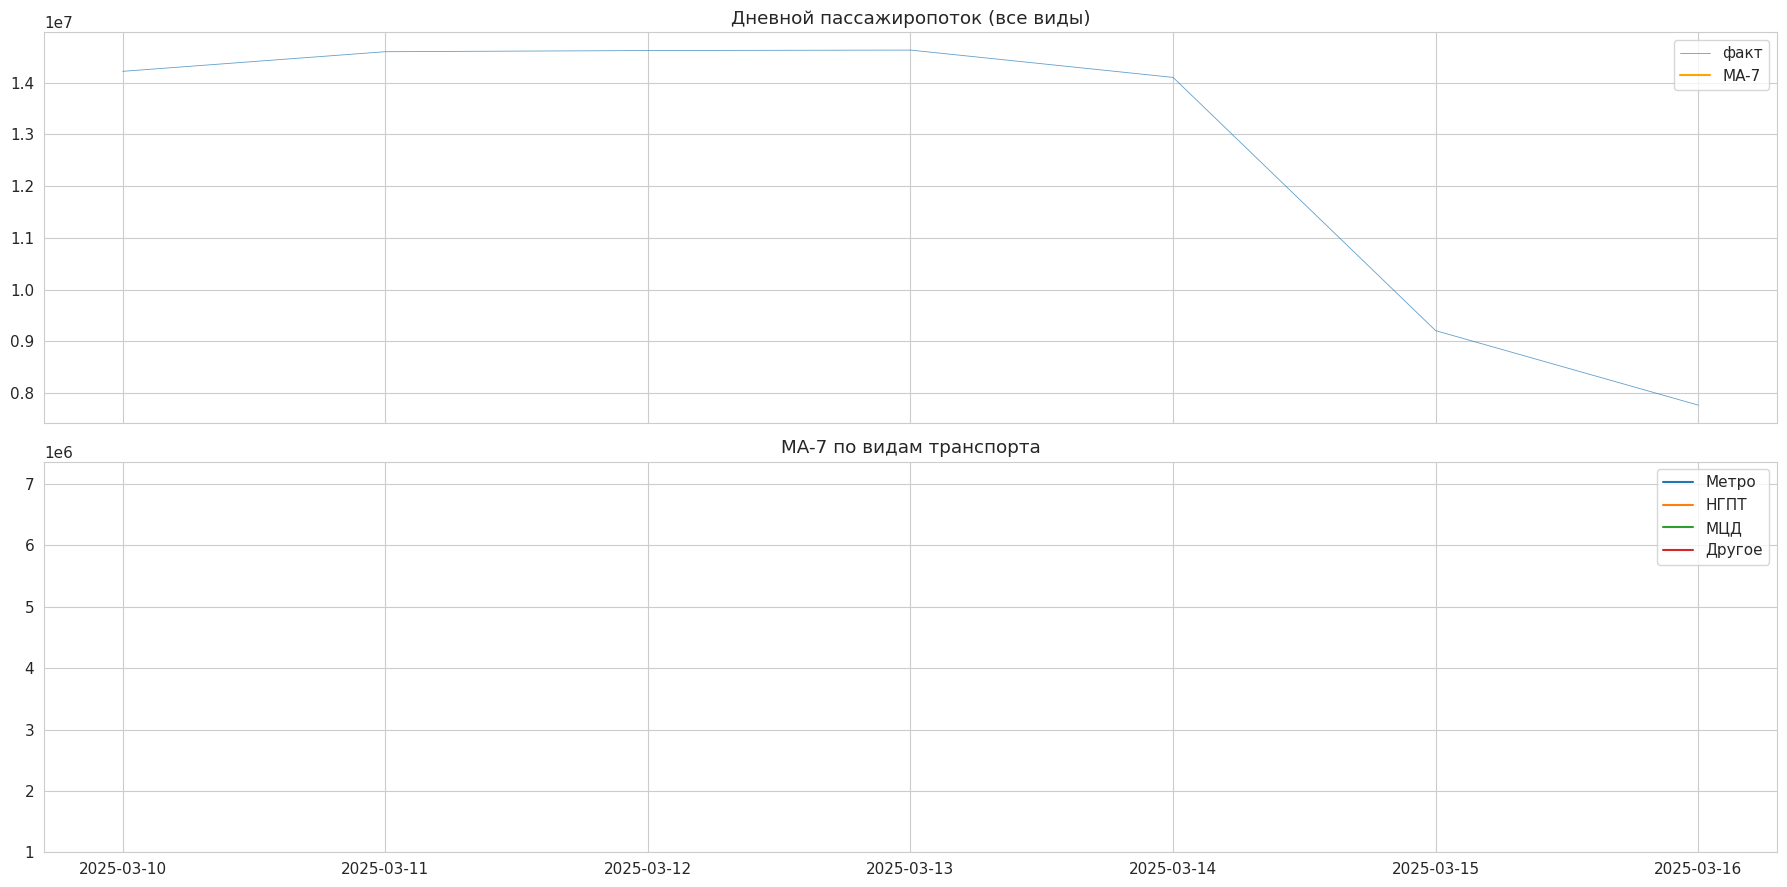

Период: 2025-03-10 -- 2025-03-16 (7 дней)
Средний: 12,734,983, мин: 7,768,780, макс: 14,629,232


In [8]:
daily = hourly.groupby('date')['pax'].sum().reset_index().sort_values('date')
daily['ma7'] = daily['pax'].rolling(7, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(18, 9), sharex=True)
axes[0].plot(daily['date'], daily['pax'], lw=0.6, alpha=0.7, label='факт')
axes[0].plot(daily['date'], daily['ma7'], lw=1.5, color='orange', label='MA-7')
axes[0].set_title('Дневной пассажиропоток (все виды)'); axes[0].legend()

daily_t = hourly.groupby(['date','tcat'])['pax'].sum().reset_index()
for cat in ['Метро','НГПТ','МЦД','Другое']:
    sub = daily_t[daily_t['tcat']==cat].sort_values('date')
    axes[1].plot(sub['date'], sub['pax'].rolling(7, center=True).mean(), lw=1.5, label=cat)
axes[1].set_title('MA-7 по видам транспорта'); axes[1].legend()
plt.tight_layout(); plt.savefig('./eda_output/01_daily_flow.png', dpi=150); plt.show()

print(f"Период: {daily['date'].min().date()} -- {daily['date'].max().date()} ({len(daily)} дней)")
print(f"Средний: {daily['pax'].mean():,.0f}, мин: {daily['pax'].min():,.0f}, макс: {daily['pax'].max():,.0f}")

## 5. Типы мест валидации

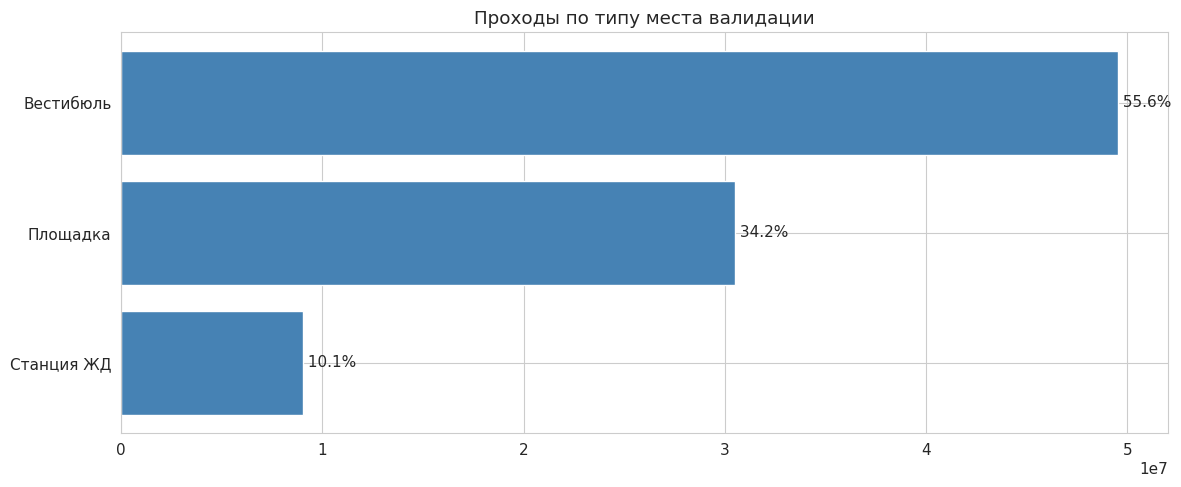

In [9]:
type_labels = {1:'Вестибюль', 2:'Остановка', 3:'Киоск', 8:'Площадка',
               9:'Платёжные терм.', 13:'Салон ТС', 15:'Станция ЖД'}
ps = hourly.groupby('TYPE_ID')['pax'].sum().reset_index()
ps['name'] = ps['TYPE_ID'].map(type_labels)
ps['pct'] = ps['pax'] / ps['pax'].sum() * 100
ps = ps.sort_values('pax', ascending=True)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(ps['name'], ps['pax'], color='steelblue')
for _, r in ps.iterrows():
    ax.text(r['pax'], ps.index.get_loc(_), f" {r['pct']:.1f}%", va='center')
ax.set_title('Проходы по типу места валидации')
plt.tight_layout(); plt.savefig('./eda_output/02_place_types.png', dpi=150); plt.show()

## 6. Часовые профили

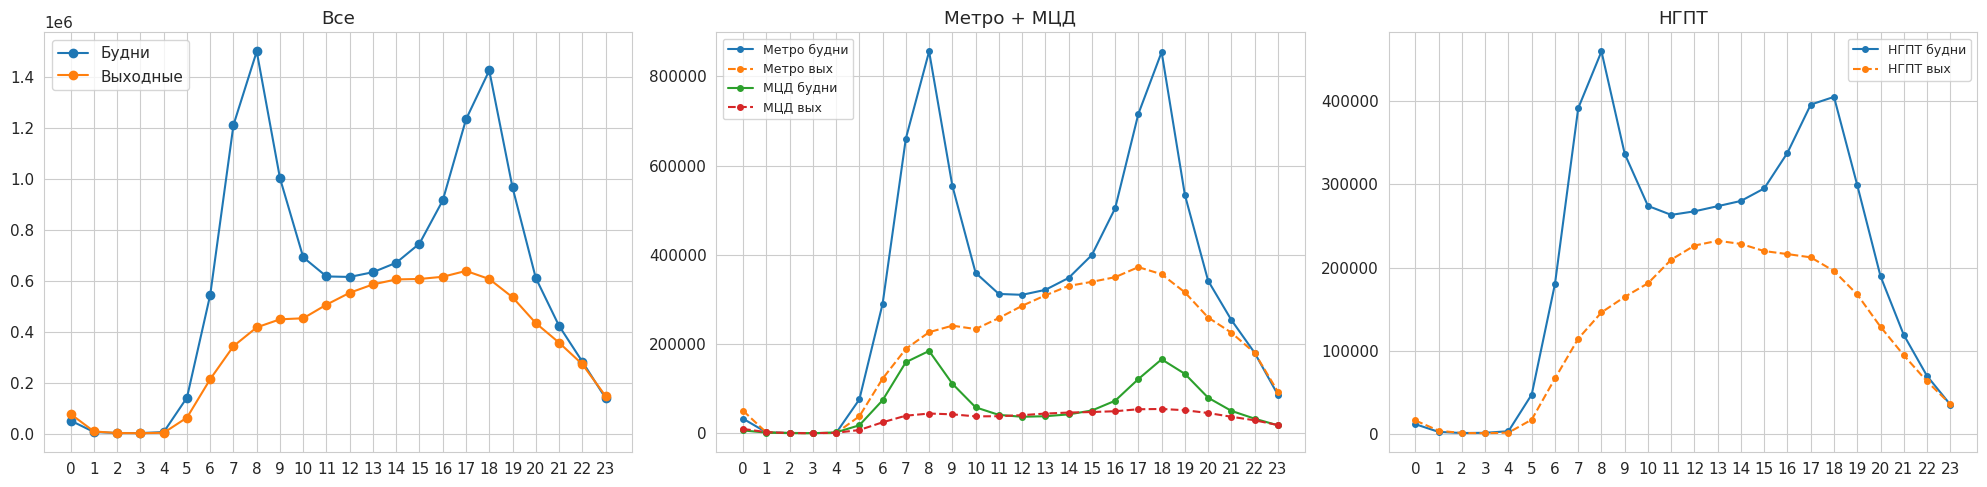

In [10]:
h_agg = hourly.groupby(['hour','is_wknd'])['pax'].sum().reset_index()
for wk in [0, 1]:
    nd = hourly[hourly['is_wknd']==wk]['date'].nunique()
    h_agg.loc[h_agg['is_wknd']==wk, 'avg'] = h_agg.loc[h_agg['is_wknd']==wk, 'pax'] / nd

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for wk, label in [(0,'Будни'),(1,'Выходные')]:
    sub = h_agg[h_agg['is_wknd']==wk]
    axes[0].plot(sub['hour'], sub['avg'], marker='o', label=label)
axes[0].set_title('Все'); axes[0].set_xticks(range(0,24)); axes[0].legend()

for tcat in ['Метро','НГПТ','МЦД']:
    sub = hourly[hourly['tcat']==tcat]
    for wk, label, ls in [(0,'будни','-'),(1,'вых','--')]:
        s2 = sub[sub['is_wknd']==wk]
        nd = s2['date'].nunique()
        if nd == 0: continue
        profile = s2.groupby('hour')['pax'].sum() / nd
        ax_idx = 1 if tcat in ['Метро','МЦД'] else 2
        axes[ax_idx].plot(profile.index, profile.values, ls=ls, marker='o', ms=4,
                          label=f'{tcat} {label}')

axes[1].set_title('Метро + МЦД'); axes[1].set_xticks(range(0,24)); axes[1].legend(fontsize=9)
axes[2].set_title('НГПТ'); axes[2].set_xticks(range(0,24)); axes[2].legend(fontsize=9)
plt.tight_layout(); plt.savefig('./eda_output/03_hourly_profiles.png', dpi=150); plt.show()

## 7. Недельный профиль

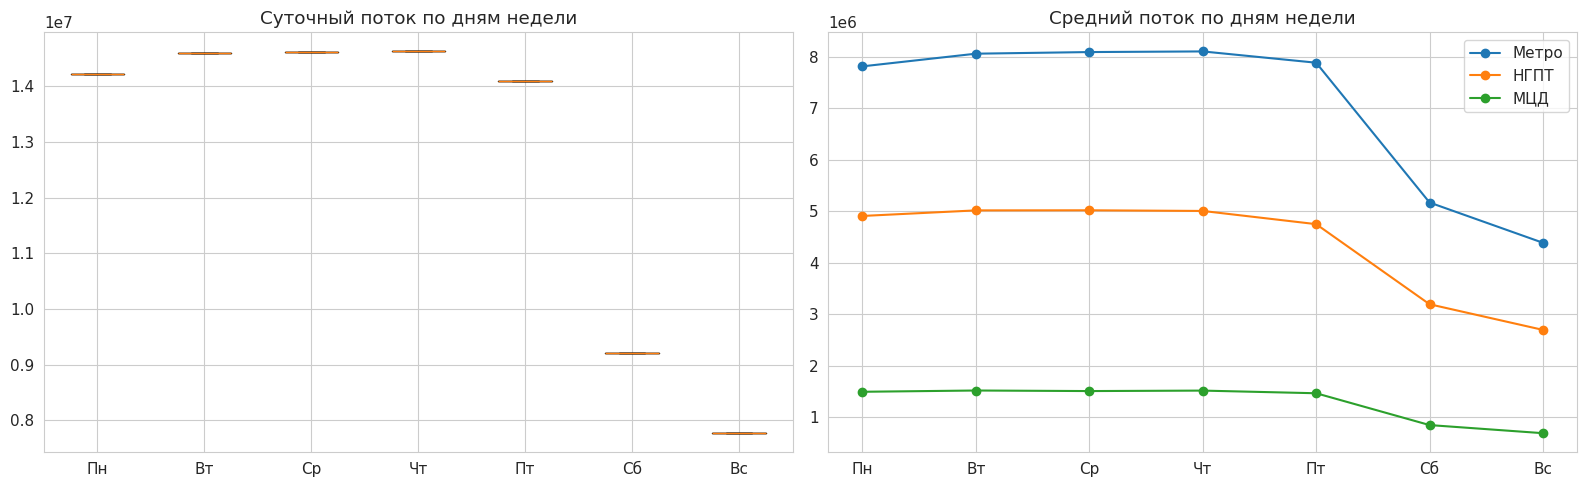

In [11]:
dow_labels = ['Пн','Вт','Ср','Чт','Пт','Сб','Вс']
daily_dow = hourly.groupby(['date','dow','tcat'])['pax'].sum().reset_index()
day_totals = hourly.groupby(['date','dow'])['pax'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].boxplot([day_totals[day_totals['dow']==d]['pax'].values for d in range(7)], labels=dow_labels)
axes[0].set_title('Суточный поток по дням недели')

for tcat in ['Метро','НГПТ','МЦД']:
    avg = daily_dow[daily_dow['tcat']==tcat].groupby('dow')['pax'].mean()
    axes[1].plot(avg.index, avg.values, marker='o', label=tcat)
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(dow_labels)
axes[1].set_title('Средний поток по дням недели'); axes[1].legend()
plt.tight_layout(); plt.savefig('./eda_output/04_weekly_profile.png', dpi=150); plt.show()

## 8. Месячная динамика

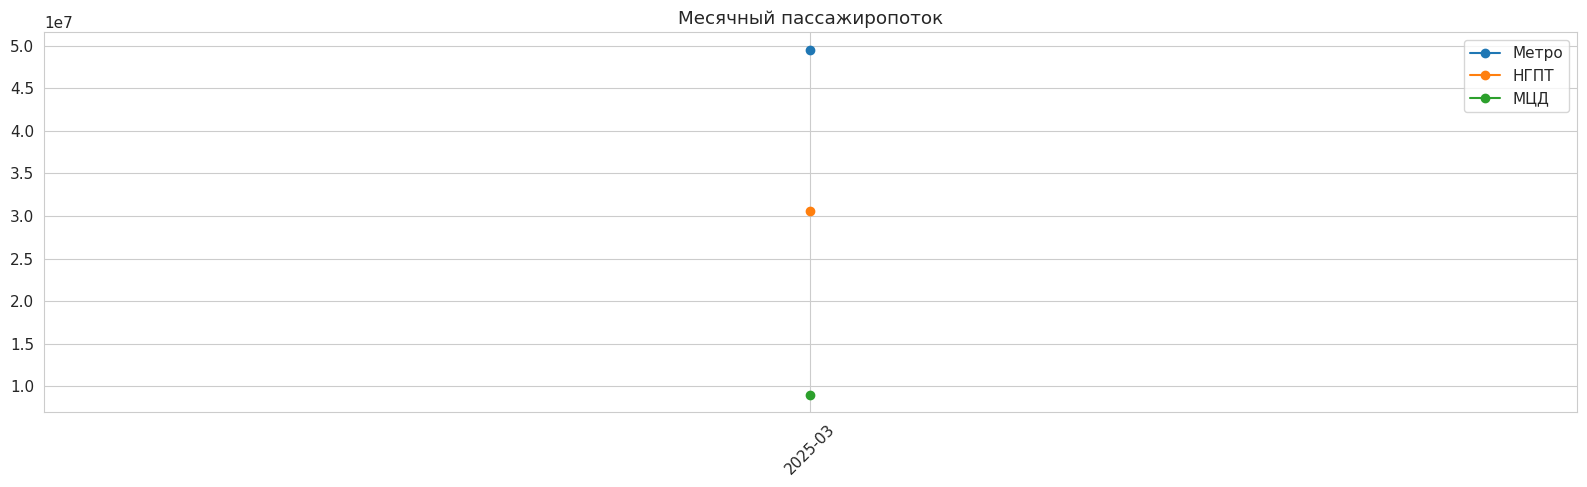

In [12]:
monthly = hourly.groupby([hourly['date'].dt.to_period('M'), 'tcat'])['pax'].sum().reset_index()
monthly['month_str'] = monthly['date'].astype(str)

fig, ax = plt.subplots(figsize=(16, 5))
for tcat in ['Метро','НГПТ','МЦД']:
    sub = monthly[monthly['tcat']==tcat]
    ax.plot(sub['month_str'], sub['pax'], marker='o', label=tcat)
ax.set_title('Месячный пассажиропоток'); plt.xticks(rotation=45); ax.legend()
plt.tight_layout(); plt.savefig('./eda_output/05_monthly.png', dpi=150); plt.show()

## 9. ТОП станций метро

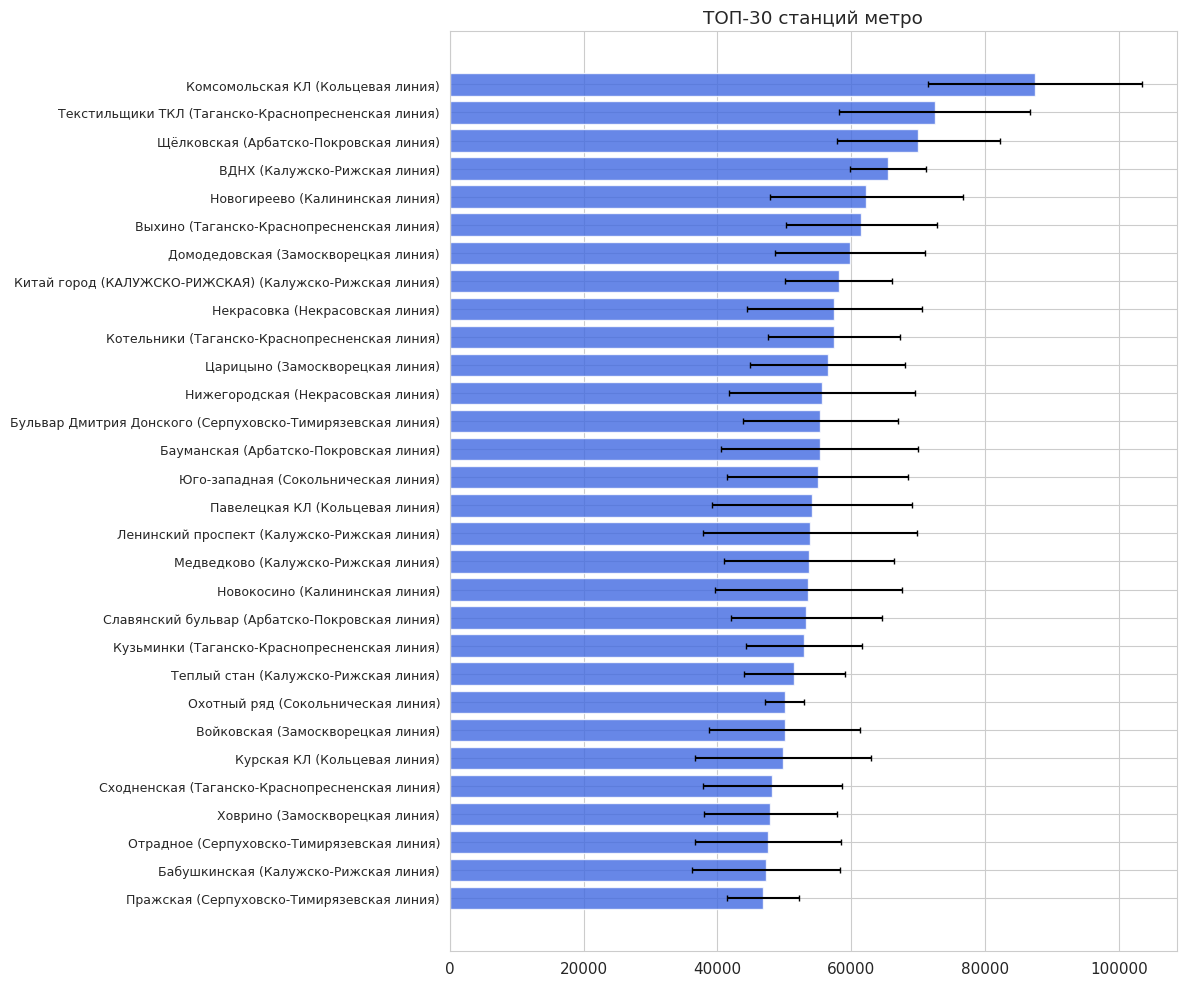

In [13]:
metro = hourly[hourly['tcat'] == 'Метро']
st_daily = metro.groupby(['date','ST_CODE','ST_NAME','LN_NAME'])['pax'].sum().reset_index()
st_avg = st_daily.groupby(['ST_CODE','ST_NAME','LN_NAME'])['pax'].agg(
    ['mean','std','median']).reset_index().sort_values('mean', ascending=False)

top30 = st_avg.head(30)
fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(range(len(top30)), top30['mean'].values, xerr=top30['std'].values,
        color='royalblue', alpha=0.8, capsize=2)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels([f"{r['ST_NAME']} ({r['LN_NAME']})" for _,r in top30.iterrows()], fontsize=9)
ax.invert_yaxis(); ax.set_title('ТОП-30 станций метро')
plt.tight_layout(); plt.savefig('./eda_output/06_top_stations.png', dpi=150); plt.show()

## 10. ТОП маршрутов НГПТ

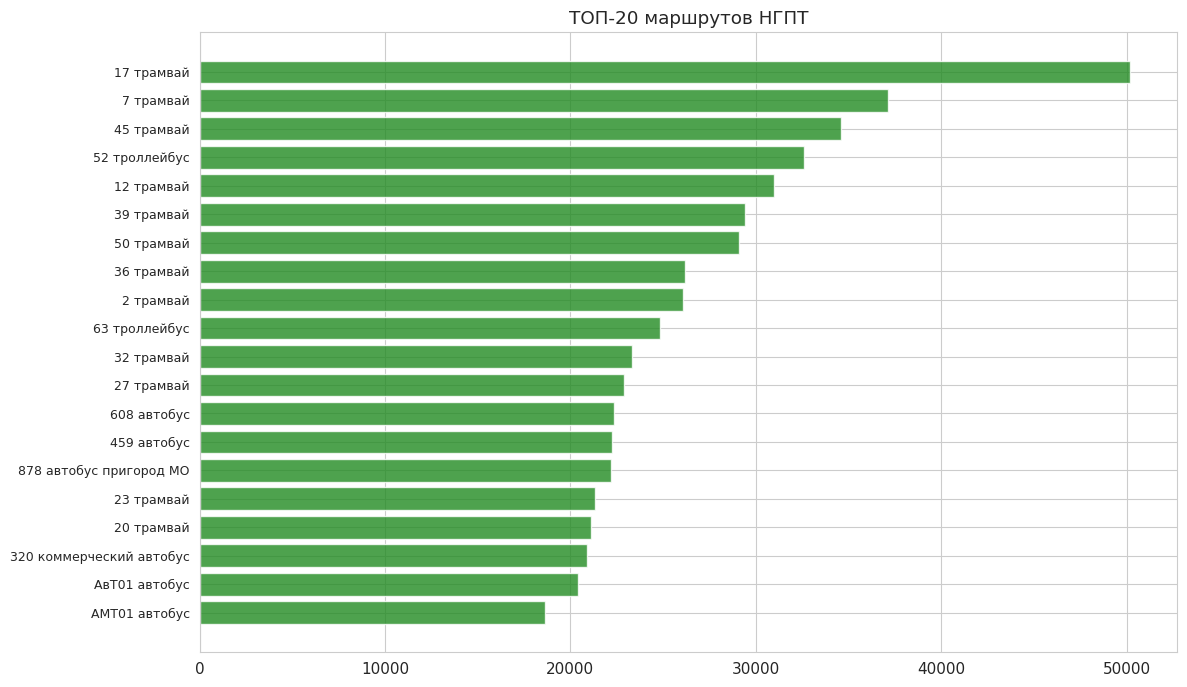

In [14]:
ngpt = hourly[hourly['tcat'] == 'НГПТ']
rt_avg = ngpt.groupby(['date','BUS_RT_NO','ROUTE_NAME'])['pax'].sum().reset_index() \
    .groupby(['BUS_RT_NO','ROUTE_NAME'])['pax'].mean().reset_index().sort_values('pax', ascending=False)

top20 = rt_avg.head(20)
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(range(len(top20)), top20['pax'].values, color='forestgreen', alpha=0.8)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['ROUTE_NAME'].fillna('?').values, fontsize=9)
ax.invert_yaxis(); ax.set_title('ТОП-20 маршрутов НГПТ')
plt.tight_layout(); plt.savefig('./eda_output/07_top_routes.png', dpi=150); plt.show()

## 11. Пересадки

  Без пересадки: 75,021,673 (91.8%)
  Внутренняя: 3,664,996 (4.5%)
  Внешняя: 2,993,545 (3.7%)


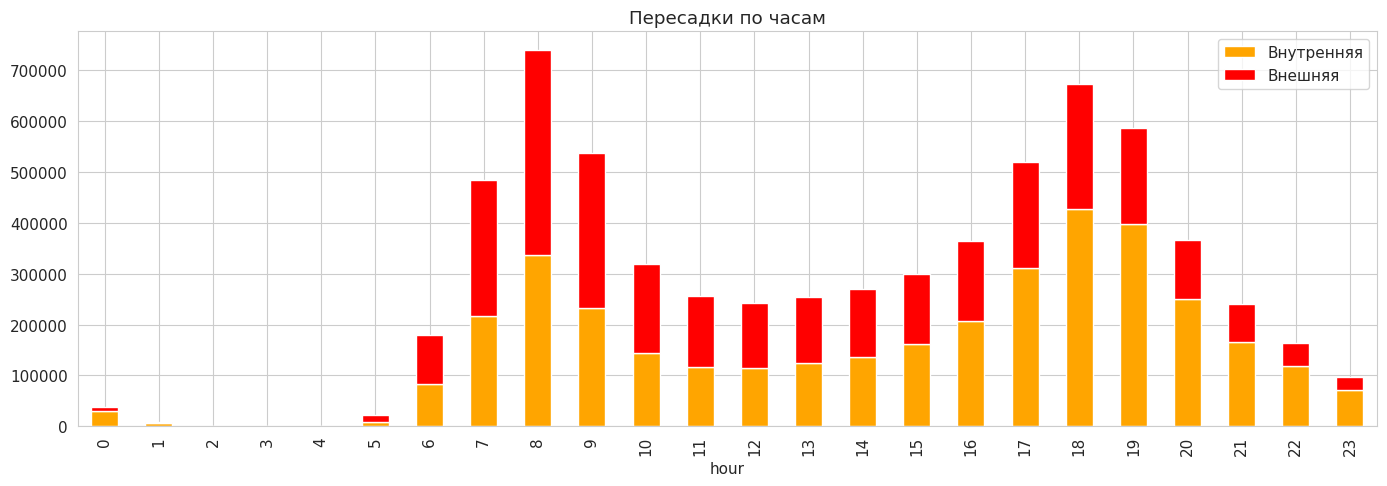

In [15]:
transfer_labels = {0:'Без пересадки', 1:'Внутренняя', 2:'Внешняя'}
tr_dist = hourly.groupby('TRANSFER_TYPE_ID')['pax'].sum()
for k, v in tr_dist.items():
    print(f"  {transfer_labels.get(k,k)}: {v:,} ({v/tr_dist.sum()*100:.1f}%)")

tr_hourly = hourly[hourly['TRANSFER_TYPE_ID'] > 0].groupby(
    ['hour','TRANSFER_TYPE_ID'])['pax'].sum().unstack(fill_value=0)
tr_hourly.columns = [transfer_labels.get(c, c) for c in tr_hourly.columns]

fig, ax = plt.subplots(figsize=(14, 5))
tr_hourly.plot(kind='bar', stacked=True, ax=ax, color=['orange','red'])
ax.set_title('Пересадки по часам')
plt.tight_layout(); plt.savefig('./eda_output/08_transfers.png', dpi=150); plt.show()

## 12. Билеты и носители

  БСК Classic: 79,599,439 (89.3%)
  ББК: 8,441,703 (9.5%)
  БСК UL: 862,558 (1.0%)
  Биометрия: 227,959 (0.3%)
  СБП: 12,910 (0.0%)


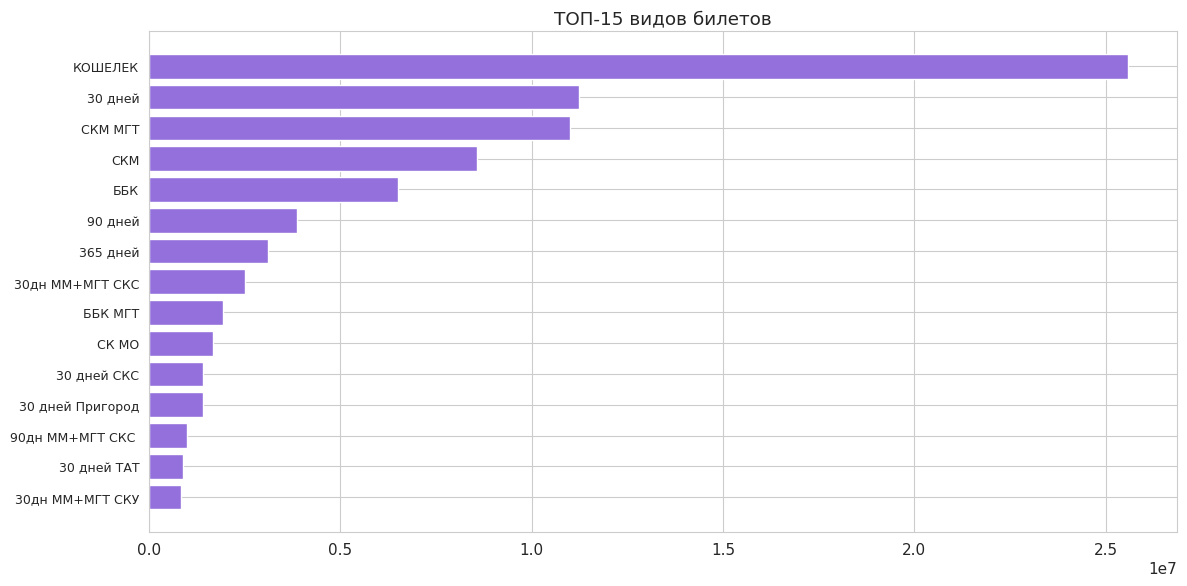

In [16]:
arch_map = {1:'БСК Classic', 2:'БСК UL', 3:'ББК', 4:'Биометрия', 5:'СБП'}
arch = hourly.groupby('ARCHITECT_ID')['pax'].sum().sort_values(ascending=False)
for k, v in arch.items():
    print(f"  {arch_map.get(k, f'? ({k})')}: {v:,} ({v/arch.sum()*100:.1f}%)")

ticket = hourly.groupby(['GD_ID','TICKET_NAME'])['pax'].sum().reset_index() \
    .sort_values('pax', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(ticket)), ticket['pax'].values, color='mediumpurple')
ax.set_yticks(range(len(ticket)))
ax.set_yticklabels(ticket['TICKET_NAME'].fillna('?').values, fontsize=9)
ax.invert_yaxis(); ax.set_title('ТОП-15 видов билетов')
plt.tight_layout(); plt.savefig('./eda_output/09_tickets.png', dpi=150); plt.show()

## 13. STL-декомпозиция, стационарность, ACF/PACF

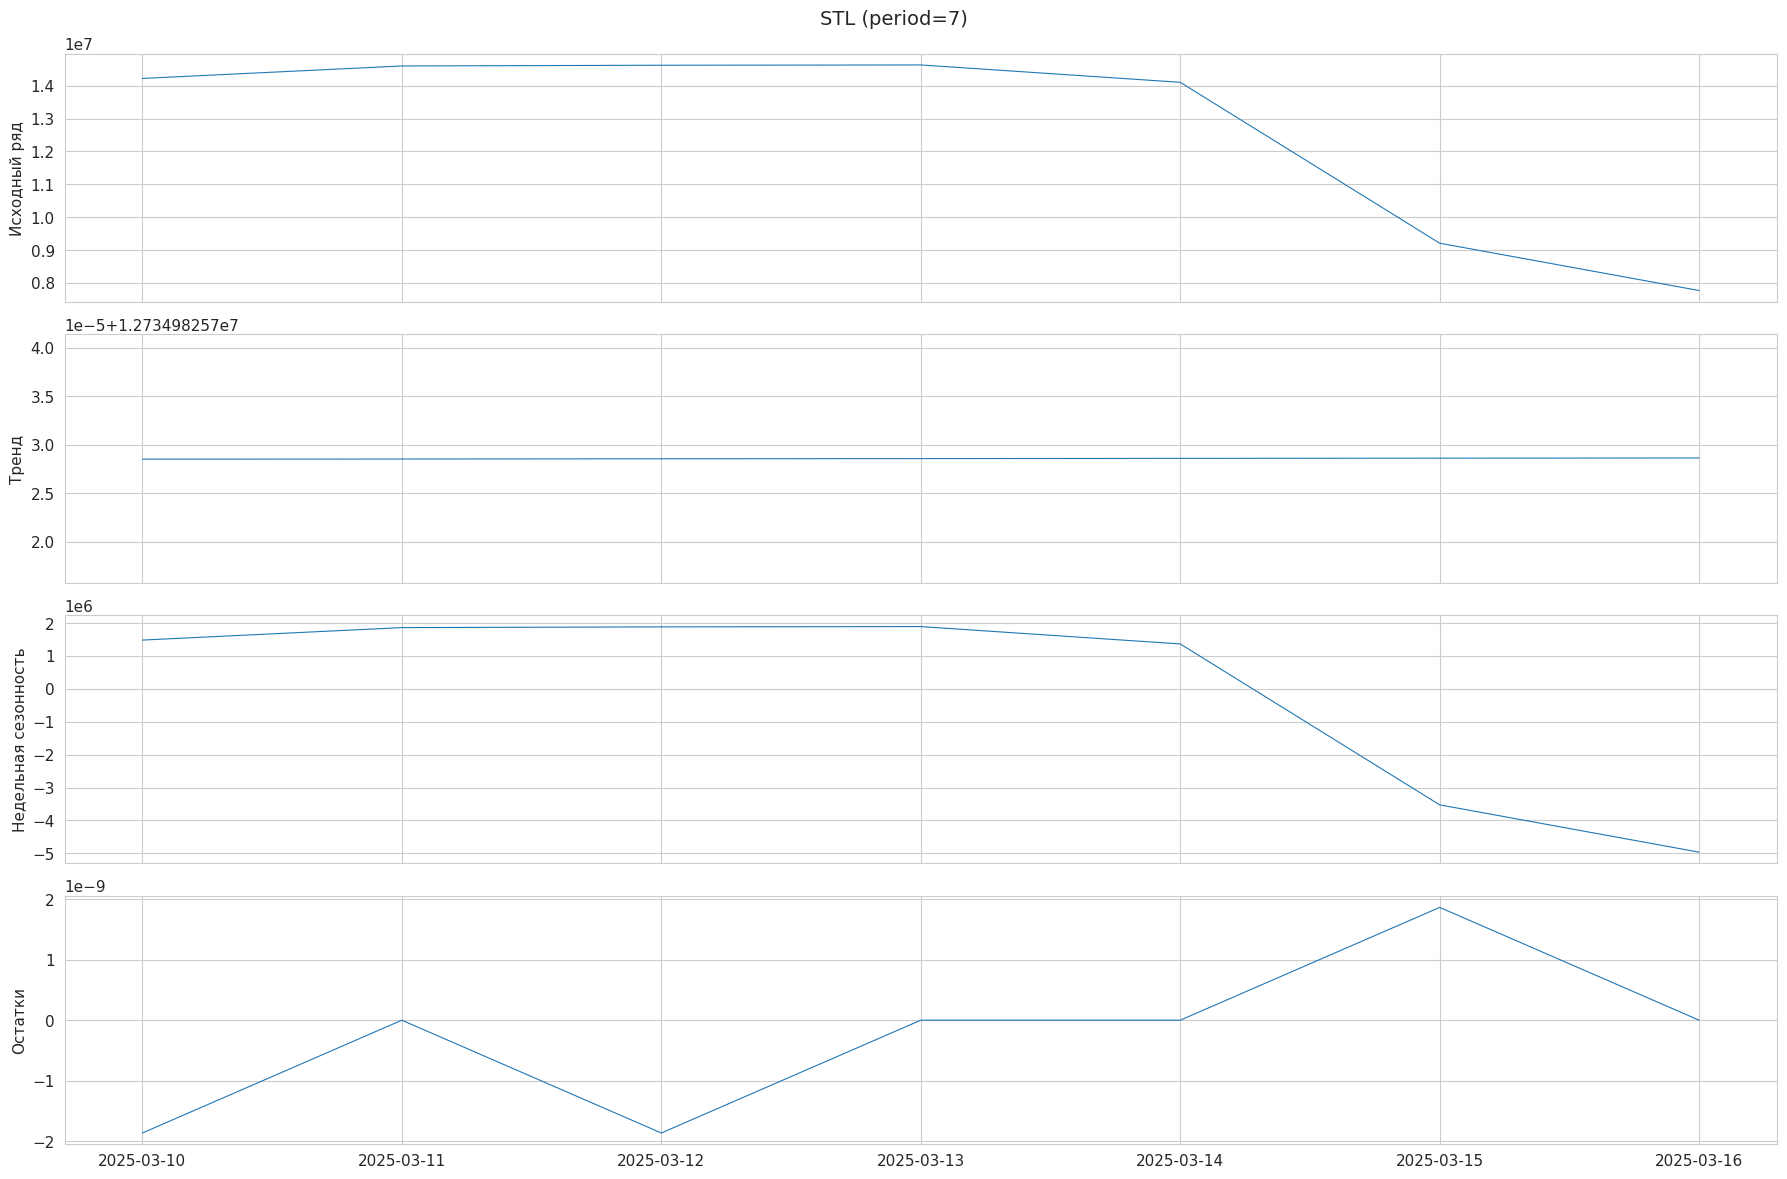

Сила сезонности: 1.000


In [17]:
ts = daily.set_index('date')['pax'].sort_index()
ts.index = pd.DatetimeIndex(ts.index)
ts = ts.asfreq('D').fillna(method='ffill')

res = STL(ts, period=7, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(18, 12), sharex=True)
for ax, data, title in zip(axes,
    [res.observed, res.trend, res.seasonal, res.resid],
    ['Исходный ряд','Тренд','Недельная сезонность','Остатки']):
    ax.plot(data, lw=0.8); ax.set_ylabel(title)
plt.suptitle('STL (period=7)', fontsize=14)
plt.tight_layout(); plt.savefig('./eda_output/10_stl.png', dpi=150); plt.show()

F_s = 1 - res.resid.var() / (res.seasonal.var() + res.resid.var())
print(f"Сила сезонности: {F_s:.3f}")

In [18]:
adf = adfuller(ts.dropna(), autolag='AIC')
print(f"ADF stat: {adf[0]:.4f}, p-value: {adf[1]:.6f}")
if adf[1] < 0.05:
    print("  -> стационарен")
else:
    print("  -> НЕ стационарен")
    adf2 = adfuller(ts.diff().dropna(), autolag='AIC')
    print(f"  d=1: ADF={adf2[0]:.4f}, p={adf2[1]:.6f}")

ADF stat: 0.3201, p-value: 0.978250
  -> НЕ стационарен
  d=1: ADF=-1.6022, p=0.482464


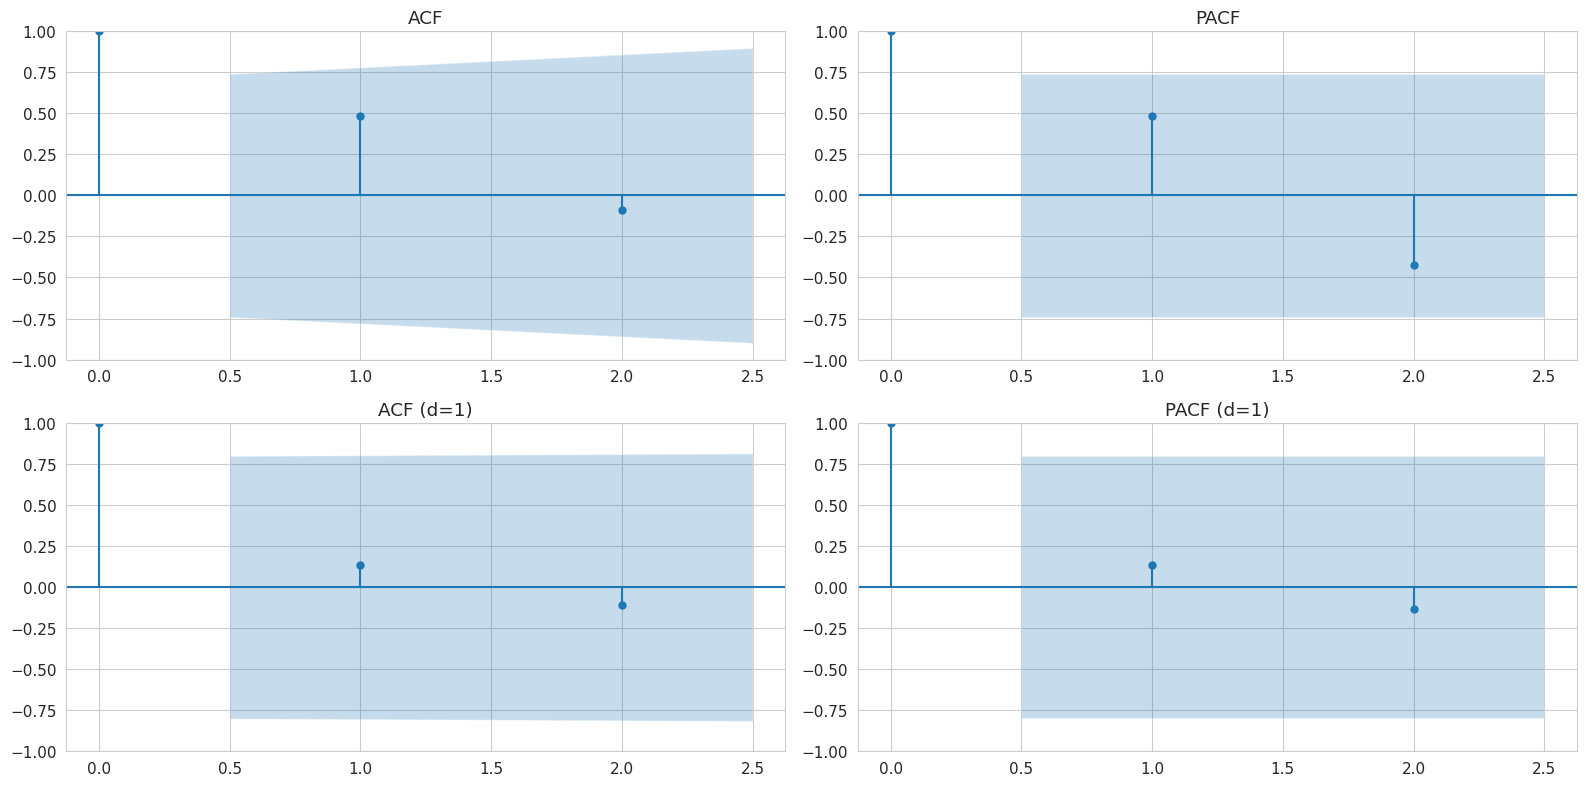

In [19]:
ts_clean = ts.dropna()
ts_diff = ts.diff().dropna()
max_lags = min(60, len(ts_clean)//2 - 1)
max_lags_d = min(60, len(ts_diff)//2 - 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
plot_acf(ts_clean, lags=max_lags, ax=axes[0,0], title='ACF')
plot_pacf(ts_clean, lags=max_lags, ax=axes[0,1], title='PACF', method='ywm')
plot_acf(ts_diff, lags=max_lags_d, ax=axes[1,0], title='ACF (d=1)')
plot_pacf(ts_diff, lags=max_lags_d, ax=axes[1,1], title='PACF (d=1)', method='ywm')
plt.tight_layout(); plt.savefig('./eda_output/11_acf_pacf.png', dpi=150); plt.show()

acf_vals = acf(ts_clean, nlags=min(30, max_lags))
for lag in [7, 14]:
    if len(acf_vals) > lag:
        print(f"ACF lag {lag}: {acf_vals[lag]:.3f}")

## 14. Динамика и профили ТОП-6 станций

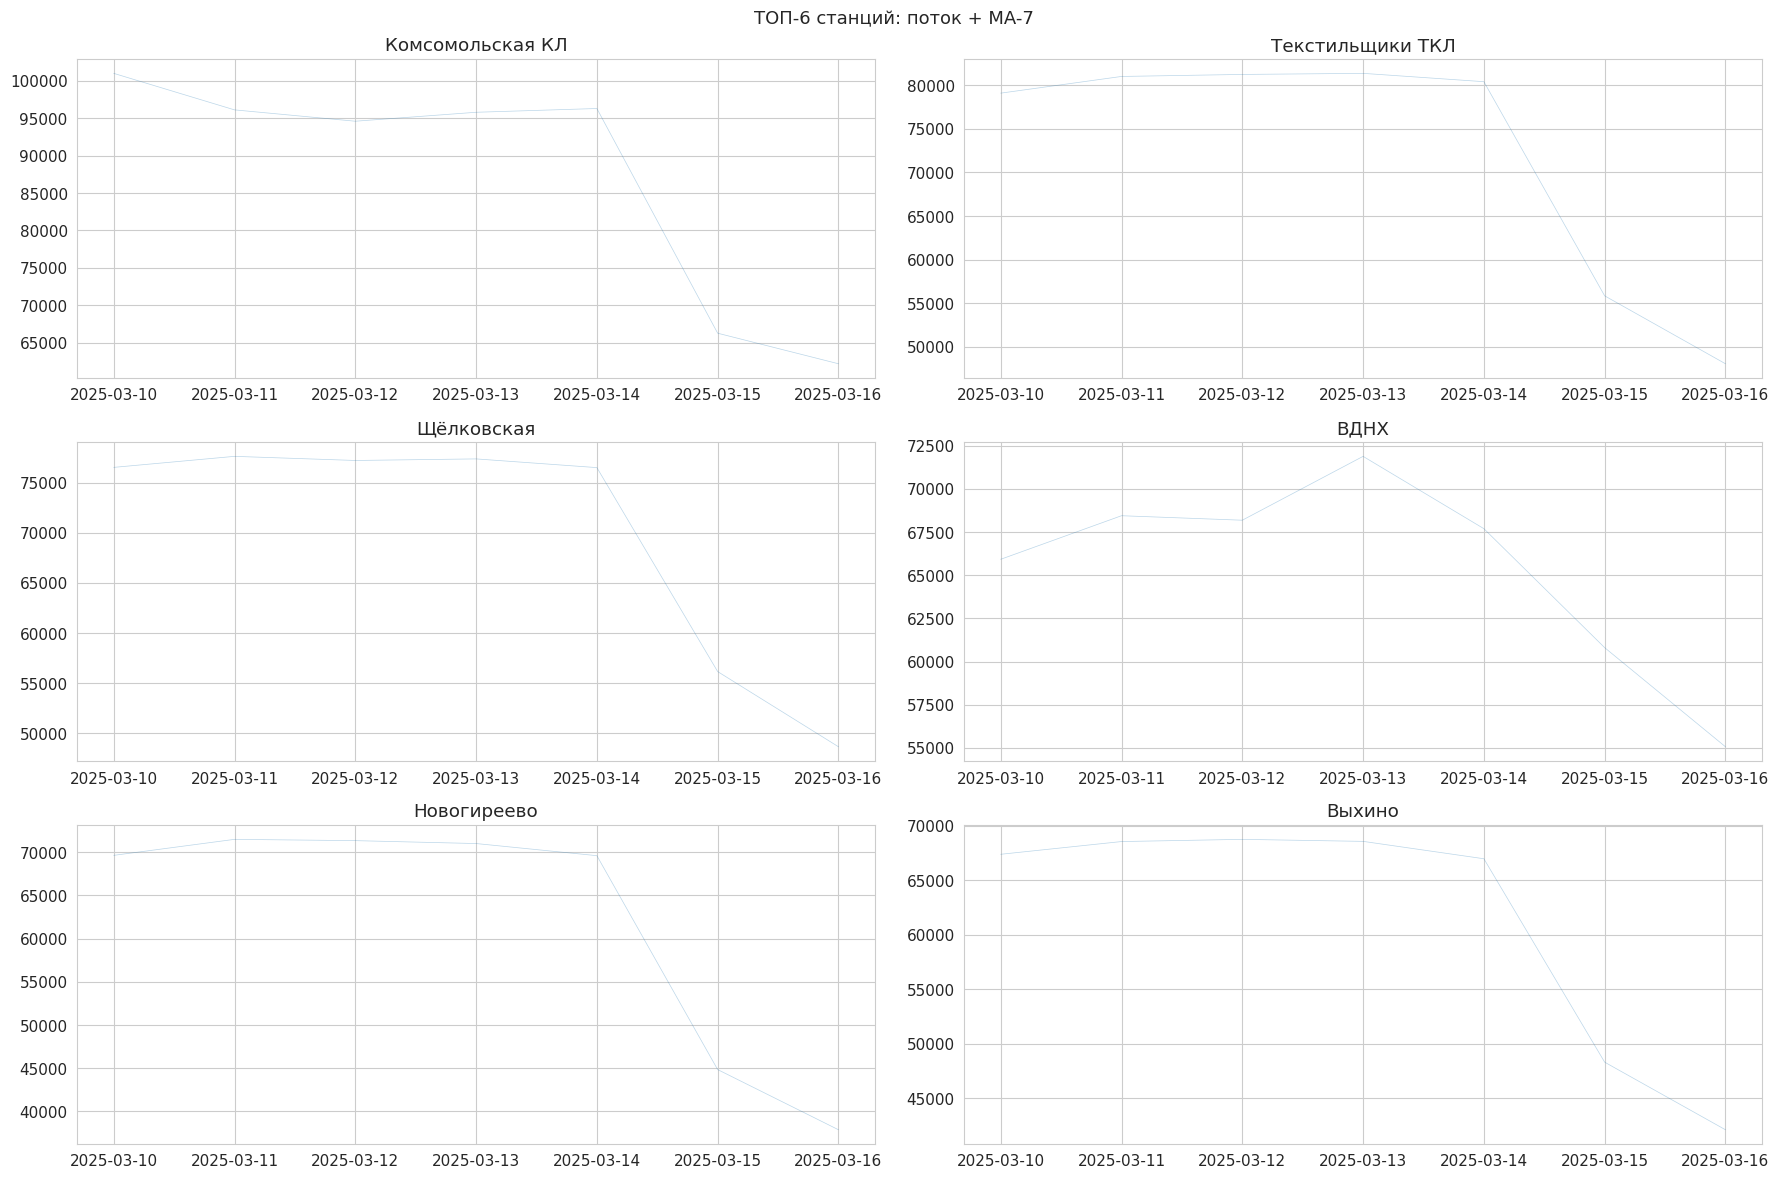

In [20]:
top6 = st_avg.head(6)['ST_CODE'].values

fig, axes = plt.subplots(3, 2, figsize=(18, 12))
for idx, st in enumerate(top6):
    ax = axes[idx//2, idx%2]
    sub = st_daily[st_daily['ST_CODE']==st].sort_values('date')
    ax.plot(sub['date'], sub['pax'], alpha=0.3, lw=0.5)
    ax.plot(sub['date'], sub['pax'].rolling(7).mean(), color='red', lw=1.5)
    ax.set_title(sub['ST_NAME'].iloc[0])
plt.suptitle('ТОП-6 станций: поток + MA-7', fontsize=13)
plt.tight_layout(); plt.savefig('./eda_output/12_station_dynamics.png', dpi=150); plt.show()

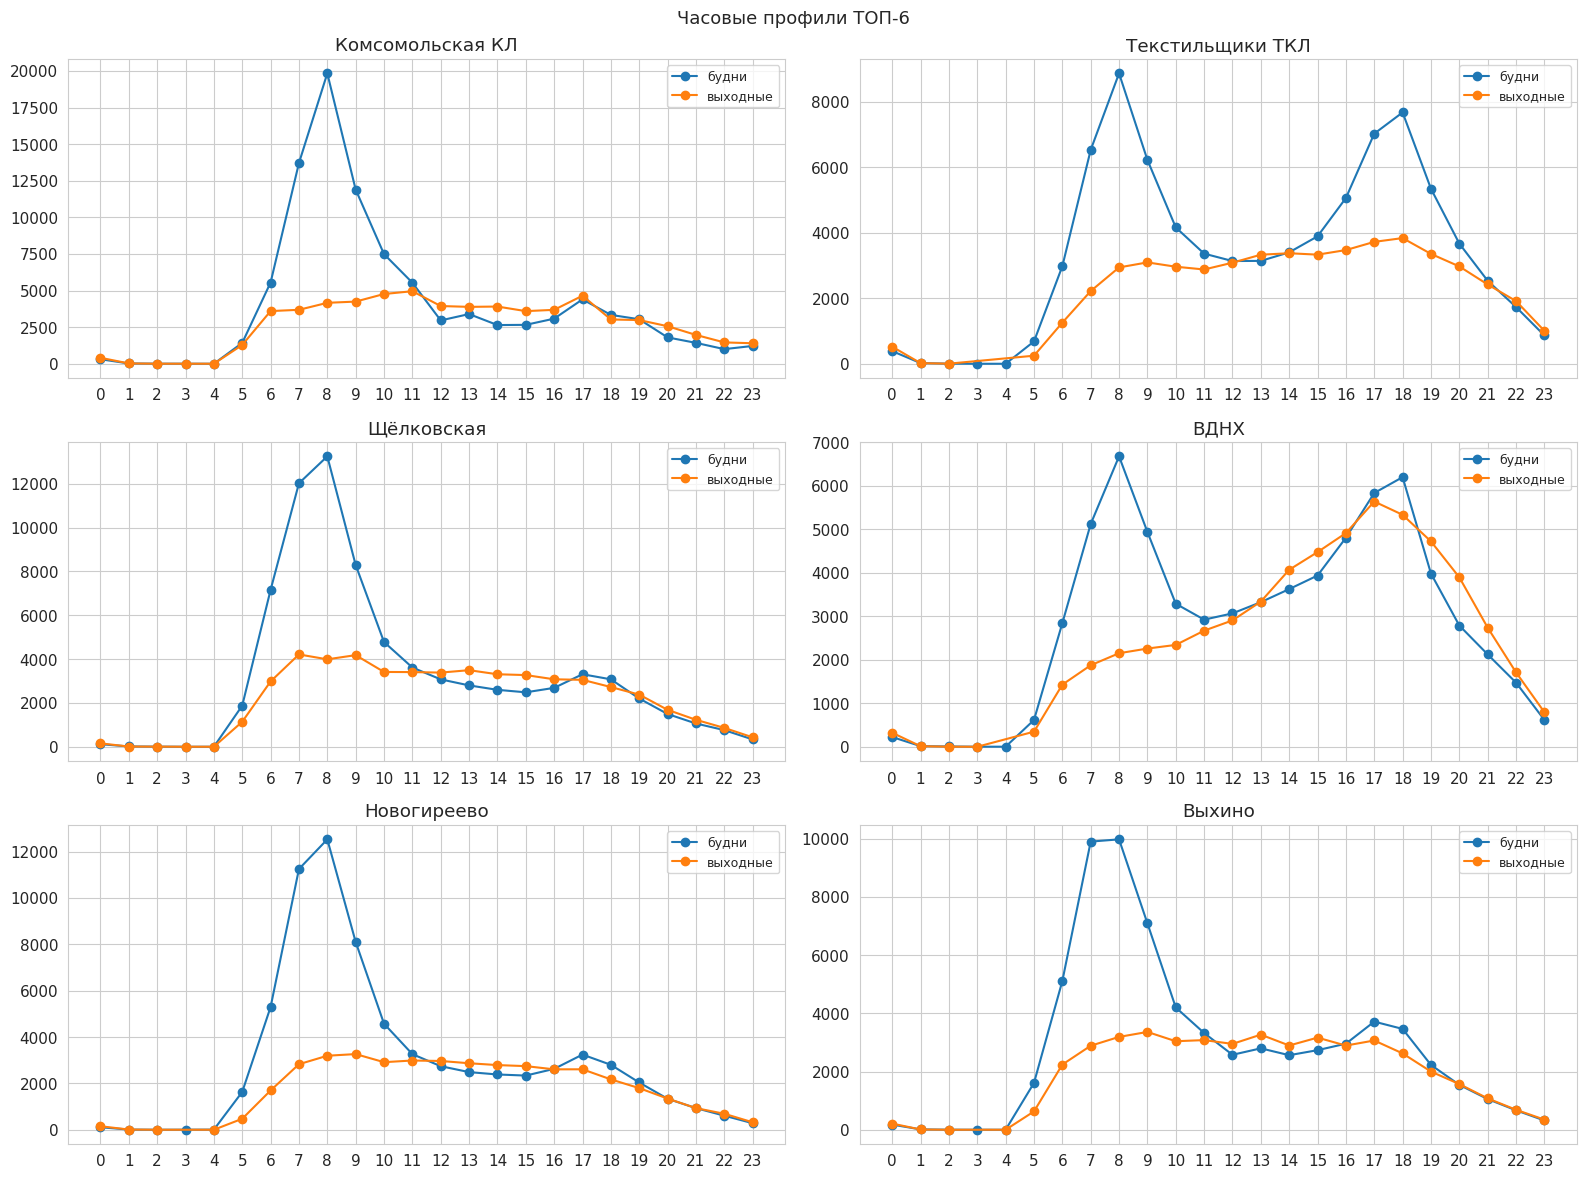

In [21]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
for idx, st in enumerate(top6):
    ax = axes[idx//2, idx%2]
    sub = metro[metro['ST_CODE']==st]
    for wk, label in [(0,'будни'),(1,'выходные')]:
        s2 = sub[sub['is_wknd']==wk]
        nd = s2['date'].nunique()
        if nd == 0: continue
        profile = s2.groupby('hour')['pax'].sum() / nd
        ax.plot(profile.index, profile.values, marker='o', label=label)
    ax.set_title(sub['ST_NAME'].iloc[0] if len(sub) else st)
    ax.set_xticks(range(0,24)); ax.legend(fontsize=9)
plt.suptitle('Часовые профили ТОП-6', fontsize=13)
plt.tight_layout(); plt.savefig('./eda_output/13_station_hourly.png', dpi=150); plt.show()

## 15. Кросс-корреляция станций

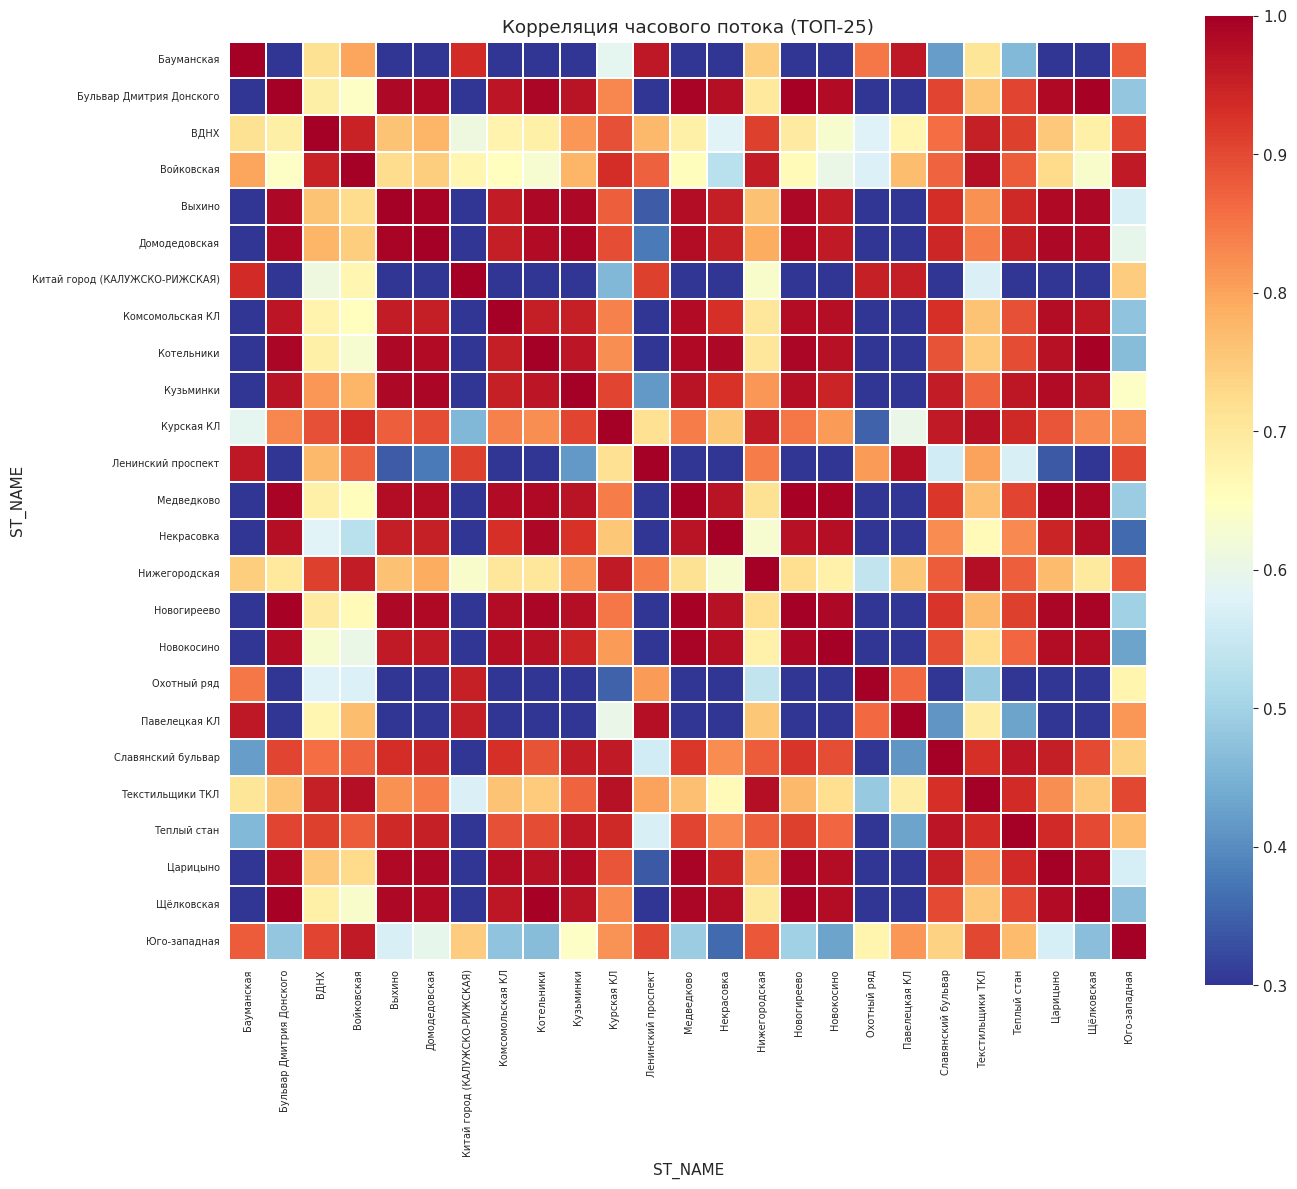

mean=0.671, median=0.796, min=-0.206


In [22]:
top_n = 25
top_st = st_avg.head(top_n)['ST_CODE'].values
pivot = metro[metro['ST_CODE'].isin(top_st)].groupby(
    ['date_hour','ST_NAME'])['pax'].sum().reset_index()
pivot = pivot.pivot_table(index='date_hour', columns='ST_NAME', values='pax', fill_value=0)
corr = pivot.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap='RdYlBu_r', vmin=0.3, vmax=1, square=True, linewidths=0.3, ax=ax)
ax.set_title(f'Корреляция часового потока (ТОП-{top_n})')
plt.xticks(fontsize=7, rotation=90); plt.yticks(fontsize=7)
plt.tight_layout(); plt.savefig('./eda_output/14_station_corr.png', dpi=150); plt.show()

upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
print(f"mean={upper.mean():.3f}, median={upper.median():.3f}, min={upper.min():.3f}")

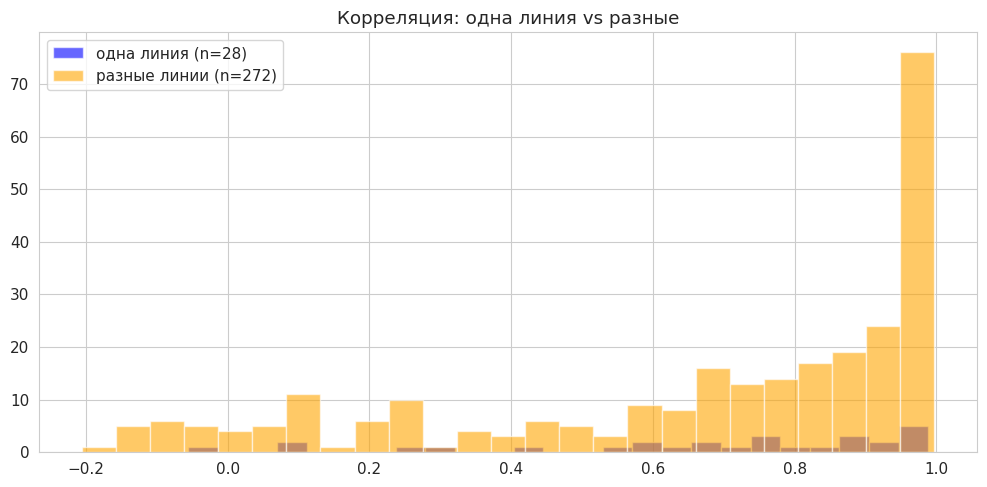

одна линия=0.677, разные=0.670


In [23]:
st_to_line = metro.drop_duplicates('ST_CODE').set_index('ST_NAME')['LN_CODE'].to_dict()
same, diff = [], []
for s1 in corr.columns:
    for s2 in corr.columns:
        if s1 >= s2: continue
        l1, l2 = st_to_line.get(s1), st_to_line.get(s2)
        if l1 is None or l2 is None: continue
        (same if l1 == l2 else diff).append(corr.loc[s1, s2])

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(same, bins=25, alpha=0.6, label=f'одна линия (n={len(same)})', color='blue')
ax.hist(diff, bins=25, alpha=0.6, label=f'разные линии (n={len(diff)})', color='orange')
ax.set_title('Корреляция: одна линия vs разные'); ax.legend()
plt.tight_layout(); plt.savefig('./eda_output/15_corr_same_vs_diff.png', dpi=150); plt.show()
print(f"одна линия={np.mean(same):.3f}, разные={np.mean(diff):.3f}")

## 16. Паттерны дней (для k-NN)

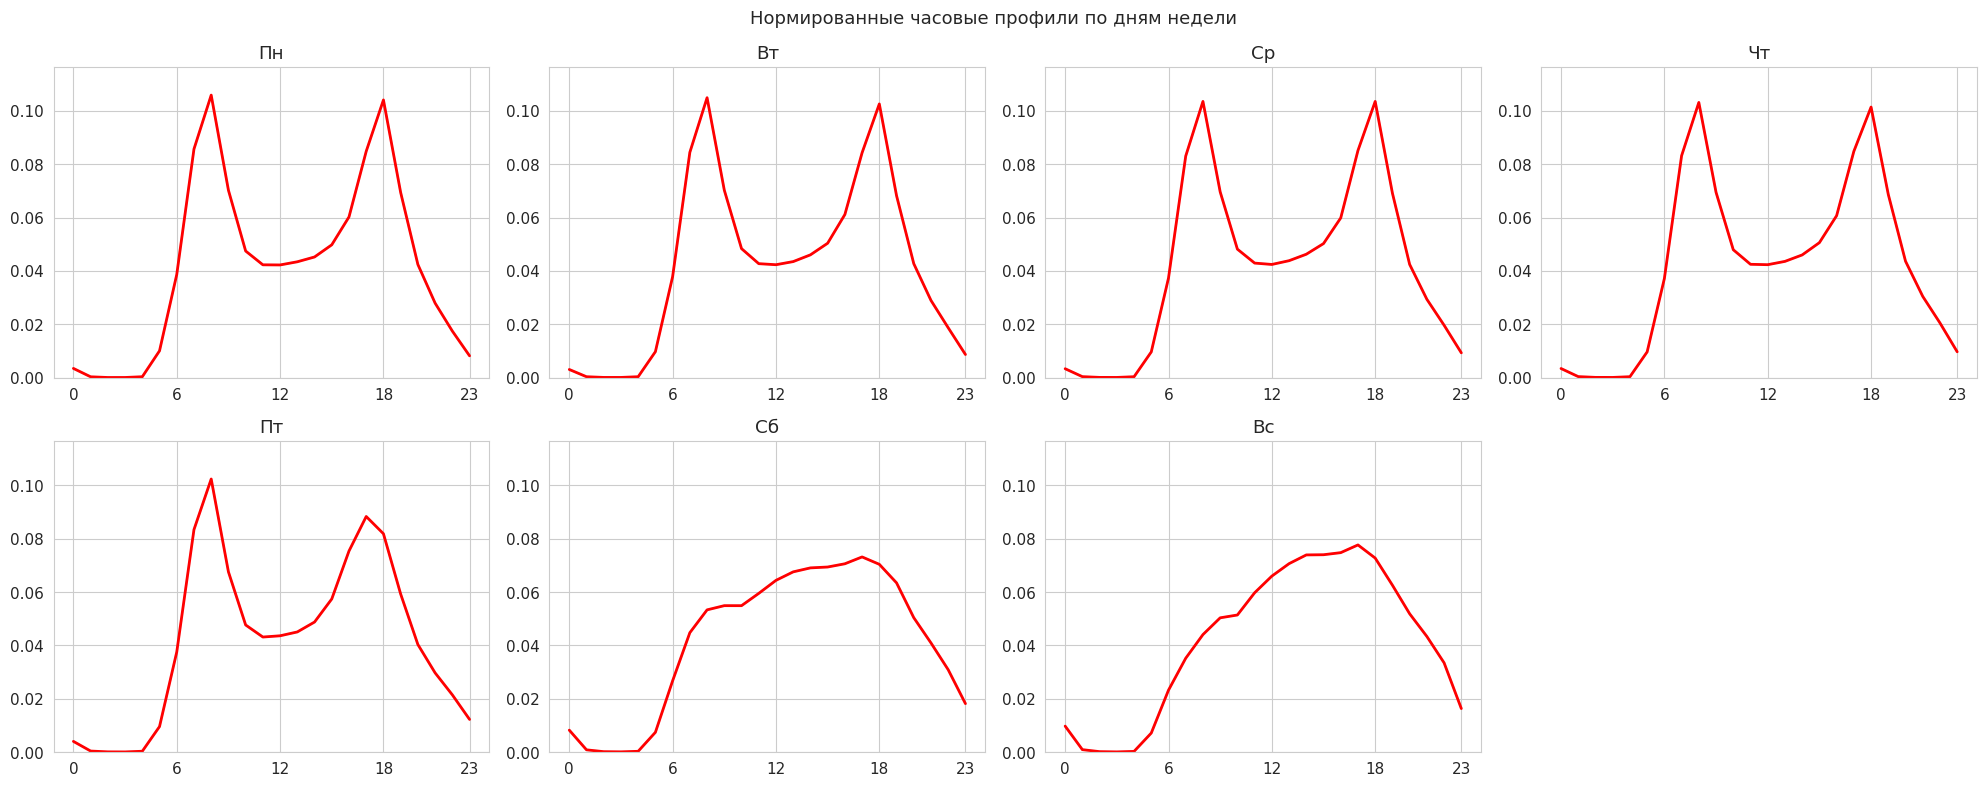

  Пн: CV = nan
  Вт: CV = nan
  Ср: CV = nan
  Чт: CV = nan
  Пт: CV = nan
  Сб: CV = nan
  Вс: CV = nan


In [24]:
piv = hourly.groupby(['date','hour'])['pax'].sum().reset_index() \
    .pivot_table(index='date', columns='hour', values='pax', fill_value=0)
piv_norm = piv.div(piv.sum(axis=1), axis=0)
piv_norm['dow'] = pd.to_datetime(piv_norm.index).dayofweek

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.ravel()
for d in range(7):
    ax = axes[d]
    profiles = piv_norm[piv_norm['dow']==d].drop(columns='dow')
    for _, row in profiles.sample(min(20, len(profiles))).iterrows():
        ax.plot(row.index, row.values, alpha=0.15, color='blue')
    ax.plot(profiles.mean().index, profiles.mean().values, color='red', lw=2)
    ax.set_title(dow_labels[d]); ax.set_xticks([0,6,12,18,23])
    ax.set_ylim(0, piv_norm.drop(columns='dow').max().max() * 1.1)
axes[7].set_visible(False)
plt.suptitle('Нормированные часовые профили по дням недели', fontsize=13)
plt.tight_layout(); plt.savefig('./eda_output/16_knn_profiles.png', dpi=150); plt.show()

for d in range(7):
    p = piv_norm[piv_norm['dow']==d].drop(columns='dow')
    print(f"  {dow_labels[d]}: CV = {(p.std()/p.mean()).mean():.3f}")

## 17. Выбросы

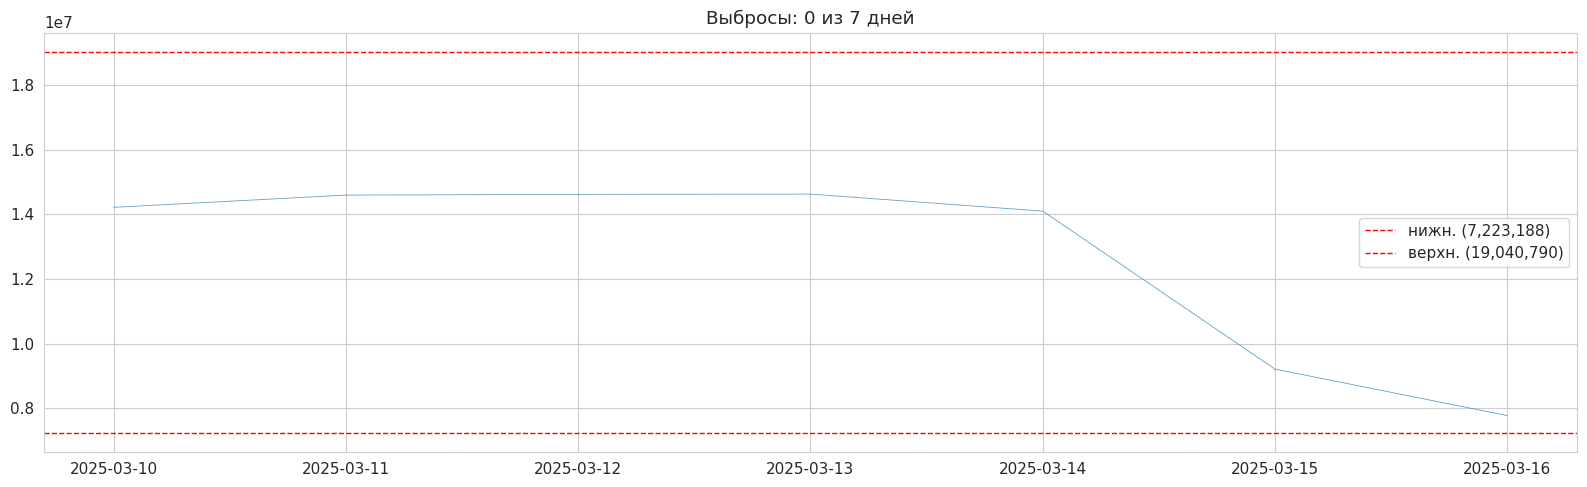

In [25]:
q1, q3 = daily['pax'].quantile(0.25), daily['pax'].quantile(0.75)
iqr = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
outliers = daily[(daily['pax'] < lo) | (daily['pax'] > hi)]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily['date'], daily['pax'], lw=0.6, alpha=0.7)
ax.axhline(lo, color='red', ls='--', lw=1, label=f'нижн. ({lo:,.0f})')
ax.axhline(hi, color='red', ls='--', lw=1, label=f'верхн. ({hi:,.0f})')
if len(outliers): ax.scatter(outliers['date'], outliers['pax'], color='red', zorder=5, s=30)
ax.set_title(f'Выбросы: {len(outliers)} из {len(daily)} дней'); ax.legend()
plt.tight_layout(); plt.savefig('./eda_output/17_outliers.png', dpi=150); plt.show()

for _, r in outliers.iterrows():
    print(f"  {r['date'].strftime('%Y-%m-%d')} ({r['date'].strftime('%A')}): {r['pax']:,}")

## 18. CV станций, операторы, вход/выход

In [26]:
cv_st = st_daily.groupby(['ST_CODE','ST_NAME'])['pax'].agg(
    lambda x: x.std()/x.mean()).reset_index(name='cv').sort_values('cv', ascending=False)
print("Нестабильные:")
print(cv_st.head(15).to_string(index=False))
print("\nСтабильные:")
print(cv_st.tail(10).to_string(index=False))

Нестабильные:
 ST_CODE                  ST_NAME       cv
  1976.0      Южный речной вокзал 0.805917
  1975.0  Кленовый бульвар причал 0.653899
  1977.0 Нагатинский затон причал 0.621579
  1979.0         Печатники причал 0.572463
  1980.0                  Новинки 0.533296
  1962.0   Краснопресненский парк 0.455952
  1512.0           Москва-Сити ФЛ 0.450643
  1972.0              Нагатинский 0.441981
  1605.0                      ВВЦ 0.441747
  1730.0          Москва-Сити МЦК 0.438759
  1971.0                      ЗИЛ 0.435159
  1745.0         Парк Победы СолЛ 0.431996
  1960.0              Кутузовский 0.418703
  1964.0           Сердце столицы 0.407395
  1904.0         Авиамоторная БКЛ 0.396842

Стабильные:
 ST_CODE           ST_NAME       cv
  1755.0              ЦСКА 0.092148
    56.0    Воробьевы горы 0.087107
   244.0              ВДНХ 0.086570
  1687.0   Битцевский парк 0.085137
   158.0      Арбатская ФЛ 0.076709
    42.0       Охотный ряд 0.058873
   133.0 Площадь Революции 0.0529

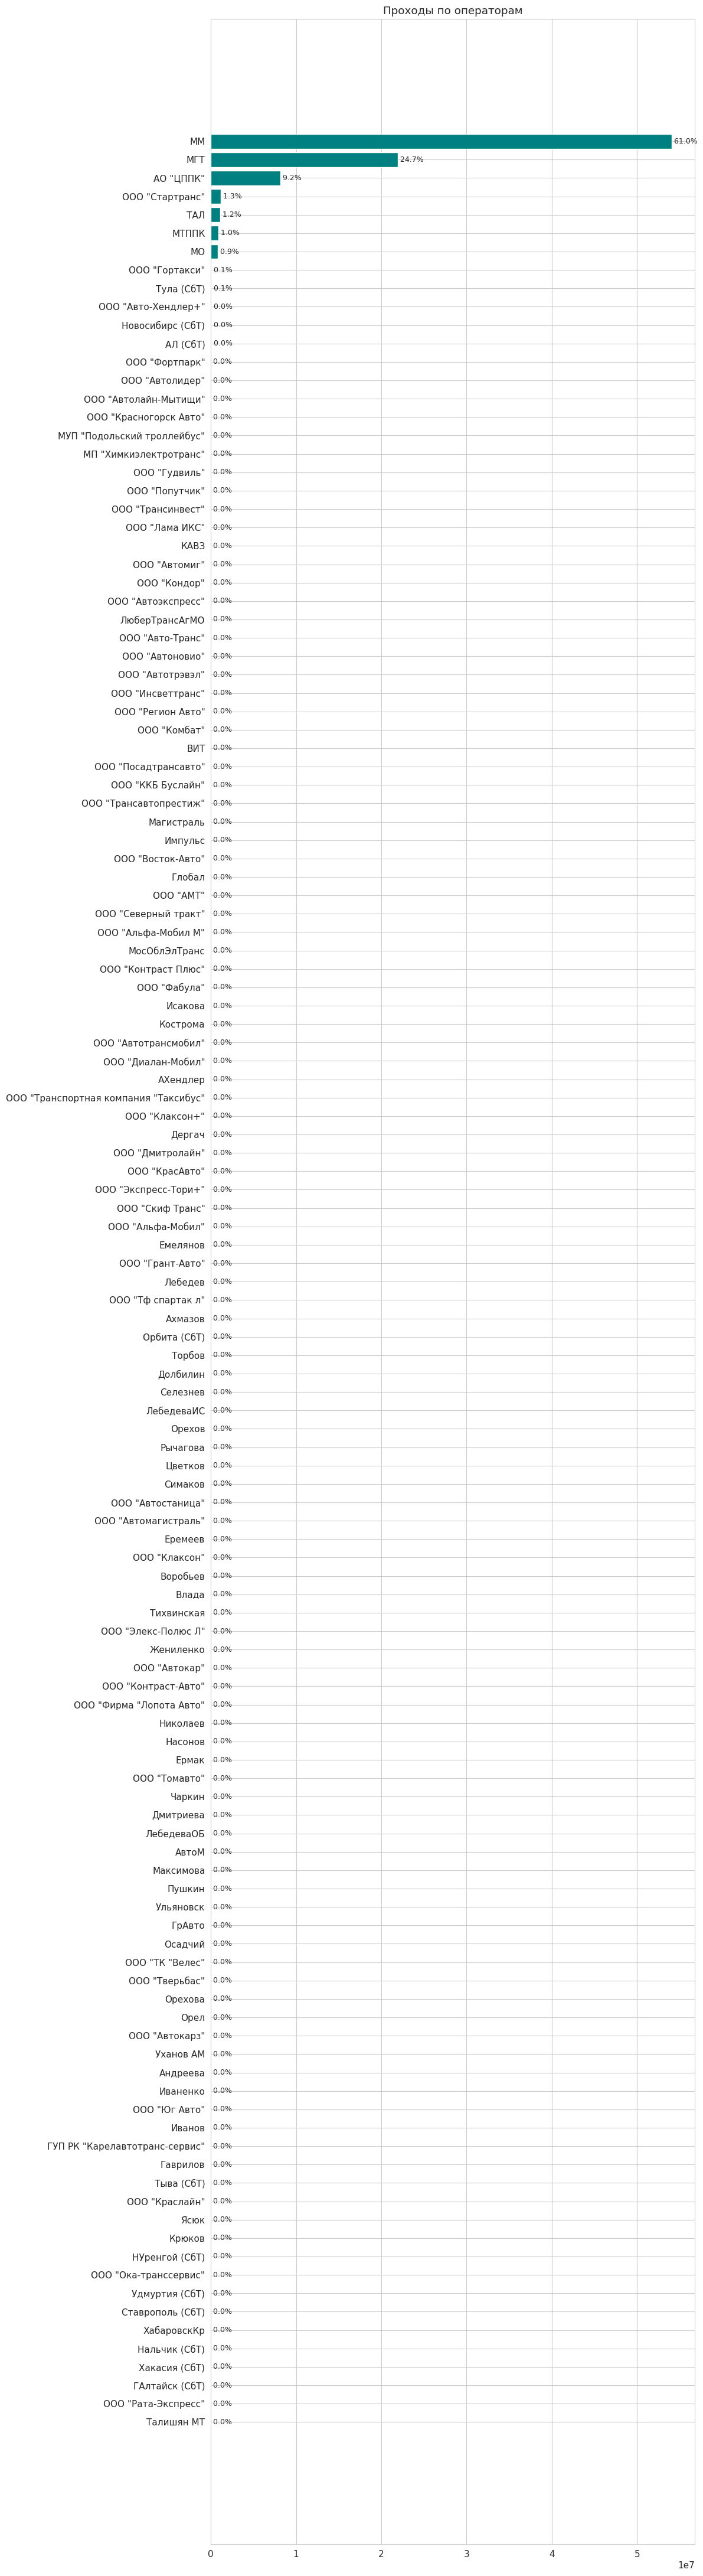

In [27]:
agent_stats = hourly.groupby('AGENT_NAME')['pax'].sum().sort_values(ascending=False)
agent_pct = agent_stats / agent_stats.sum() * 100

fig, ax = plt.subplots(figsize=(12, max(4, len(agent_stats)*0.35)))
ax.barh(range(len(agent_stats)), agent_stats.values, color='teal')
ax.set_yticks(range(len(agent_stats))); ax.set_yticklabels(agent_stats.index)
ax.invert_yaxis(); ax.set_title('Проходы по операторам')
for i, (v, p) in enumerate(zip(agent_stats.values, agent_pct.values)):
    ax.text(v, i, f' {p:.1f}%', va='center', fontsize=9)
plt.tight_layout(); plt.savefig('./eda_output/18_agents.png', dpi=150); plt.show()

In [28]:
if hourly['VALIDATION_MODE'].notna().any():
    vm = hourly.groupby('VALIDATION_MODE')['pax'].sum()
    print(f"Вход={vm.get(1,0):,}, Выход={vm.get(2,0):,}")

if hourly['CPPC_VALIDATION_TYPE'].notna().any():
    cppc_labels = {0:'Вход', 1:'Выход', 2:'Штатное заверш.', 3:'Принуд. заверш.',
                   4:'Доплата', 5:'Искусств. заверш. (ДП)', 6:'Искусств. вход'}
    cppc = hourly.groupby('CPPC_VALIDATION_TYPE')['pax'].sum()
    for k, v in cppc.items():
        print(f"  {cppc_labels.get(k,k)}: {v:,}")

Вход=84,821,336, Выход=4,323,542
  Вход: 4,289,798
  Выход: 4,229,410
  Принуд. заверш.: 94,132
  Искусств. вход: 34,168


## 19. Целевые датасеты

In [29]:
metro_target = metro.groupby(['date_hour','ST_CODE','ST_NAME','LN_CODE','LN_NAME'])['pax'].sum().reset_index(name='y')
metro_target.to_parquet('./eda_output/metro_hourly_target.parquet', index=False)

ngpt_target = ngpt.groupby(['date_hour','BUS_RT_NO','ROUTE_NAME'])['pax'].sum().reset_index(name='y')
ngpt_target.to_parquet('./eda_output/ngpt_hourly_target.parquet', index=False)

print(f"metro: {len(metro_target):,} строк, {metro_target['ST_CODE'].nunique()} станций")
print(f"ngpt:  {len(ngpt_target):,} строк, {ngpt_target['BUS_RT_NO'].nunique()} маршрутов")

metro: 48,315 строк, 314 станций
ngpt:  61,314 строк, 462 маршрутов


---
# Кластеризация (метро + НГПТ + МЦД)

In [30]:
def build_profiles(subset, id_col, name_col):
    """Часовой профиль будней/выходных + мета-признаки."""
    subset = subset.copy()
    subset['is_wknd'] = (subset['dow'] >= 5).astype(int)
    rows = []
    for obj_id in subset[id_col].dropna().unique():
        d = subset[subset[id_col] == obj_id]
        obj_name = d[name_col].iloc[0] if name_col in d.columns else '?'

        wd = d[d['is_wknd']==0]
        nd_wd = wd['date'].nunique()
        if nd_wd == 0: continue
        wd_h = wd.groupby('hour')['pax'].sum() / nd_wd
        wd_tot = wd_h.sum()
        if wd_tot == 0: continue

        we = d[d['is_wknd']==1]
        nd_we = we['date'].nunique()
        we_h = we.groupby('hour')['pax'].sum() / nd_we if nd_we > 0 else pd.Series(dtype=float)
        we_tot = we_h.sum() if nd_we > 0 else 0

        r = {'object_id': obj_id, 'object_name': obj_name, 'daily_volume': wd_tot}
        for h in range(24):
            r[f'wd_h{h}'] = wd_h.get(h, 0) / wd_tot
            r[f'we_h{h}'] = (we_h.get(h, 0) / we_tot) if we_tot > 0 else 0

        morn = sum(wd_h.get(h, 0) for h in [7,8,9])
        eve = sum(wd_h.get(h, 0) for h in [17,18,19])
        r['morn_eve_ratio'] = morn / eve if eve > 0 else 1.0
        r['we_wd_ratio'] = we_tot / wd_tot if wd_tot > 0 else 0
        r['peakiness'] = wd_h.max() / (wd_tot / 24)
        r['night_share'] = sum(wd_h.get(h, 0) for h in [23,0,1,2,3,4,5]) / wd_tot
        r['midday_share'] = sum(wd_h.get(h, 0) for h in [11,12,13,14]) / wd_tot
        rows.append(r)
    return pd.DataFrame(rows)

# собираем профили по видам транспорта
metro_f = build_profiles(hourly[hourly['tcat']=='Метро'], 'ST_CODE', 'ST_NAME')
metro_f['transport'] = 'Метро'
sm = metro.drop_duplicates('ST_CODE').set_index('ST_CODE')
metro_f['LN_CODE'] = metro_f['object_id'].map(sm['LN_CODE'])
metro_f['LN_NAME'] = metro_f['object_id'].map(sm['LN_NAME'])

ngpt_f = build_profiles(hourly[hourly['tcat']=='НГПТ'], 'BUS_RT_NO', 'ROUTE_NAME')
ngpt_f['transport'] = 'НГПТ'
ngpt_f['LN_CODE'] = ngpt_f['LN_NAME'] = None

parts = [metro_f, ngpt_f]
mcd = hourly[hourly['tcat']=='МЦД']
if mcd['ST_CODE'].nunique() > 2:
    mcd_f = build_profiles(mcd, 'ST_CODE', 'ST_NAME')
    mcd_f['transport'] = 'МЦД'
    sm2 = mcd.drop_duplicates('ST_CODE').set_index('ST_CODE')
    mcd_f['LN_CODE'] = mcd_f['object_id'].map(sm2['LN_CODE'])
    mcd_f['LN_NAME'] = mcd_f['object_id'].map(sm2['LN_NAME'])
    parts.append(mcd_f)

all_feat = pd.concat(parts, ignore_index=True)
print(f"Объектов: {len(all_feat)}")

Объектов: 1646


### Чистка + подбор k

После чистки: 1542


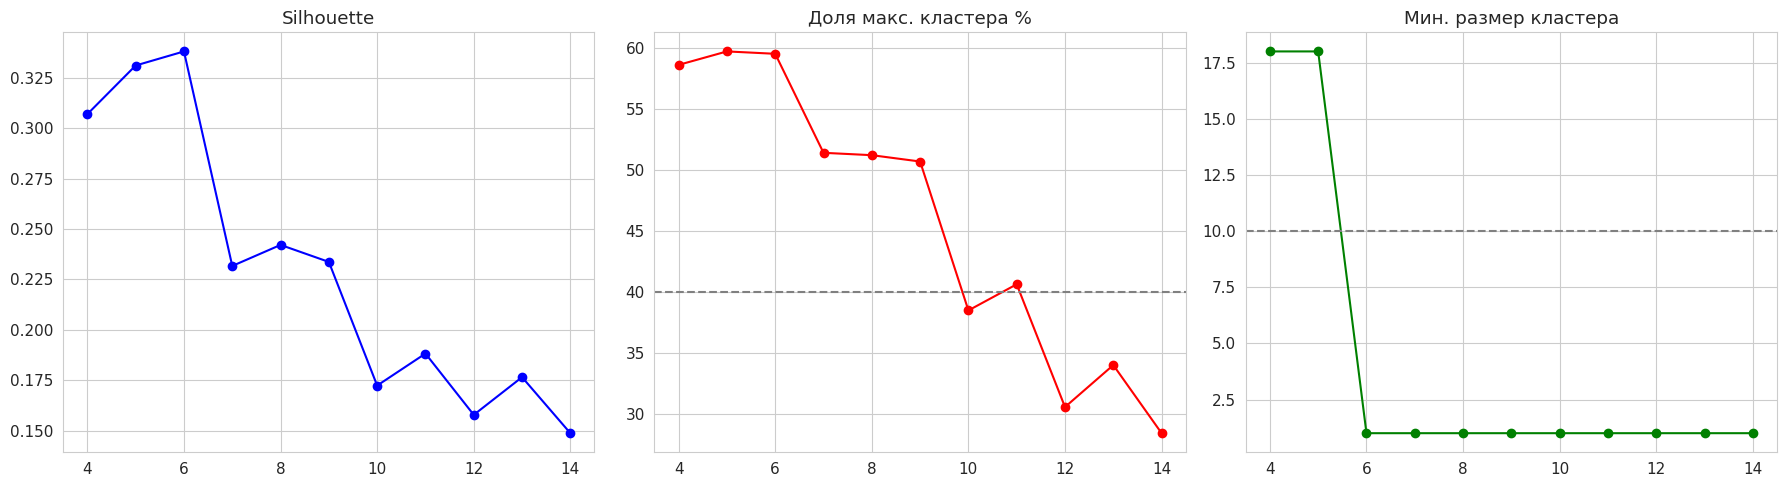

k = 11


In [31]:
af = all_feat[(all_feat['daily_volume'] >= 50) &
              (all_feat['peakiness'] < 15) &
              (all_feat['we_wd_ratio'] > 0)].copy()
af['object_name'] = af['object_name'].fillna(af['transport'] + '_' + af['object_id'].astype(str))
print(f"После чистки: {len(af)}")

af['log_volume'] = np.log1p(af['daily_volume'])
profile_cols = [f'wd_h{h}' for h in range(24)]
feat_cols = profile_cols + ['morn_eve_ratio','we_wd_ratio','peakiness',
                            'night_share','midday_share','log_volume']

X = StandardScaler().fit_transform(af[feat_cols].values)

res = []
for k in range(4, 15):
    lab = KMeans(k, n_init=30, random_state=42).fit_predict(X)
    sizes = pd.Series(lab).value_counts()
    res.append({'k': k, 'sil': silhouette_score(X, lab),
                'min_cl': sizes.min(), 'max_share': sizes.max()/len(lab)})
rdf = pd.DataFrame(res)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(rdf.k, rdf.sil, 'bo-'); axes[0].set_title('Silhouette')
axes[1].plot(rdf.k, rdf.max_share*100, 'ro-'); axes[1].axhline(40, c='gray', ls='--')
axes[1].set_title('Доля макс. кластера %')
axes[2].plot(rdf.k, rdf.min_cl, 'go-'); axes[2].axhline(10, c='gray', ls='--')
axes[2].set_title('Мин. размер кластера')
plt.tight_layout(); plt.savefig('./eda_output/clust_01_k_selection.png', dpi=150); plt.show()

good = rdf[(rdf.max_share < 0.40) & (rdf.min_cl >= 10)]
if len(good) == 0:
    good = rdf[rdf.max_share < 0.50]
best_k = int(good.loc[good.sil.idxmax(), 'k'])
print(f"k = {best_k}")

In [32]:
km = KMeans(best_k, n_init=50, random_state=42)
af['cluster'] = km.fit_predict(X)

# сливаем мелкие кластеры (<10 объектов) с ближайшим крупным
sizes = af['cluster'].value_counts()
small = sizes[sizes < 10].index.tolist()
if small:
    centers = km.cluster_centers_
    for sc in small:
        dists = np.linalg.norm(centers - centers[sc], axis=1)
        dists[sc] = np.inf
        for s2 in small:
            if s2 != sc: dists[s2] = np.inf
        nearest = np.argmin(dists)
        af.loc[af.cluster == sc, 'cluster'] = nearest
        print(f"  {sc} -> {nearest}")
    mapping = {old: new for new, old in enumerate(sorted(af.cluster.unique()))}
    af['cluster'] = af.cluster.map(mapping)

final_k = af.cluster.nunique()
print(f"Кластеров: {final_k}")
print(af.cluster.value_counts().sort_index())

  7 -> 0
  4 -> 0
  8 -> 1
Кластеров: 8
cluster
0     14
1    285
2    193
3    225
4    116
5     96
6    595
7     18
Name: count, dtype: int64


### Описание кластеров

In [33]:
for c in sorted(af.cluster.unique()):
    sub = af[af.cluster == c]
    me, vol = sub.morn_eve_ratio.mean(), sub.daily_volume.mean()
    label = "ЖИЛОЙ" if me > 1.3 else ("ДЕЛОВОЙ" if me < 0.75 else "СМЕШАННЫЙ")
    if vol > 20000: label += " крупный"
    elif vol < 2000: label += " мелкий"
    n_m = (sub.transport=='Метро').sum()
    n_n = (sub.transport=='НГПТ').sum()
    n_d = (sub.transport=='МЦД').sum()
    print(f"\nC{c} -- {label}  [{len(sub)} объектов: М:{n_m} Н:{n_n} Д:{n_d}]")
    print(f"  объем={vol:,.0f}/день  у/в={me:.2f}  вых/буд={sub.we_wd_ratio.mean():.2f}")
    for _, s in sub.nlargest(5, 'daily_volume').iterrows():
        print(f"    {s.transport} | {s.object_name} ({s.daily_volume:,.0f}/д)")


C0 -- СМЕШАННЫЙ мелкий  [14 объектов: М:1 Н:13 Д:0]
  объем=1,381/день  у/в=0.78  вых/буд=0.79
    НГПТ | НГПТ_7383.0 (5,492/д)
    НГПТ | НГПТ_4003.0 (1,639/д)
    НГПТ | 50К трамвай (1,631/д)
    НГПТ | НГПТ_4112.0 (1,504/д)
    НГПТ | Ш2 автобус (1,266/д)

C1 -- СМЕШАННЫЙ  [285 объектов: М:14 Н:271 Д:0]
  объем=3,905/день  у/в=1.14  вых/буд=0.72
    НГПТ | 12 трамвай (35,294/д)
    НГПТ | НГПТ_4012.0 (27,003/д)
    НГПТ | АвТ01 автобус (23,263/д)
    НГПТ | 34 трамвай (21,895/д)
    НГПТ | АМТ01 автобус (21,491/д)

C2 -- СМЕШАННЫЙ  [193 объектов: М:0 Н:43 Д:150]
  объем=2,398/день  у/в=1.19  вых/буд=0.58
    МЦД | Горьковское 2001070 ЖЕЛЕЗНОДОРОЖНАЯ (35,767/д)
    МЦД | Ленинградское 2005615 ЗЕЛЕНОГРАД-КРЮКОВО (23,320/д)
    МЦД | Курское 2000065 ПОДОЛЬСК (22,225/д)
    МЦД | Рижское 2000460 НАХАБИНО (21,147/д)
    МЦД | Курское 2000285 ЩЕРБИНКА (18,076/д)

C3 -- СМЕШАННЫЙ  [225 объектов: М:61 Н:57 Д:107]
  объем=12,146/день  у/в=1.09  вых/буд=0.53
    НГПТ | НГПТ_7201.0 (130,162/д

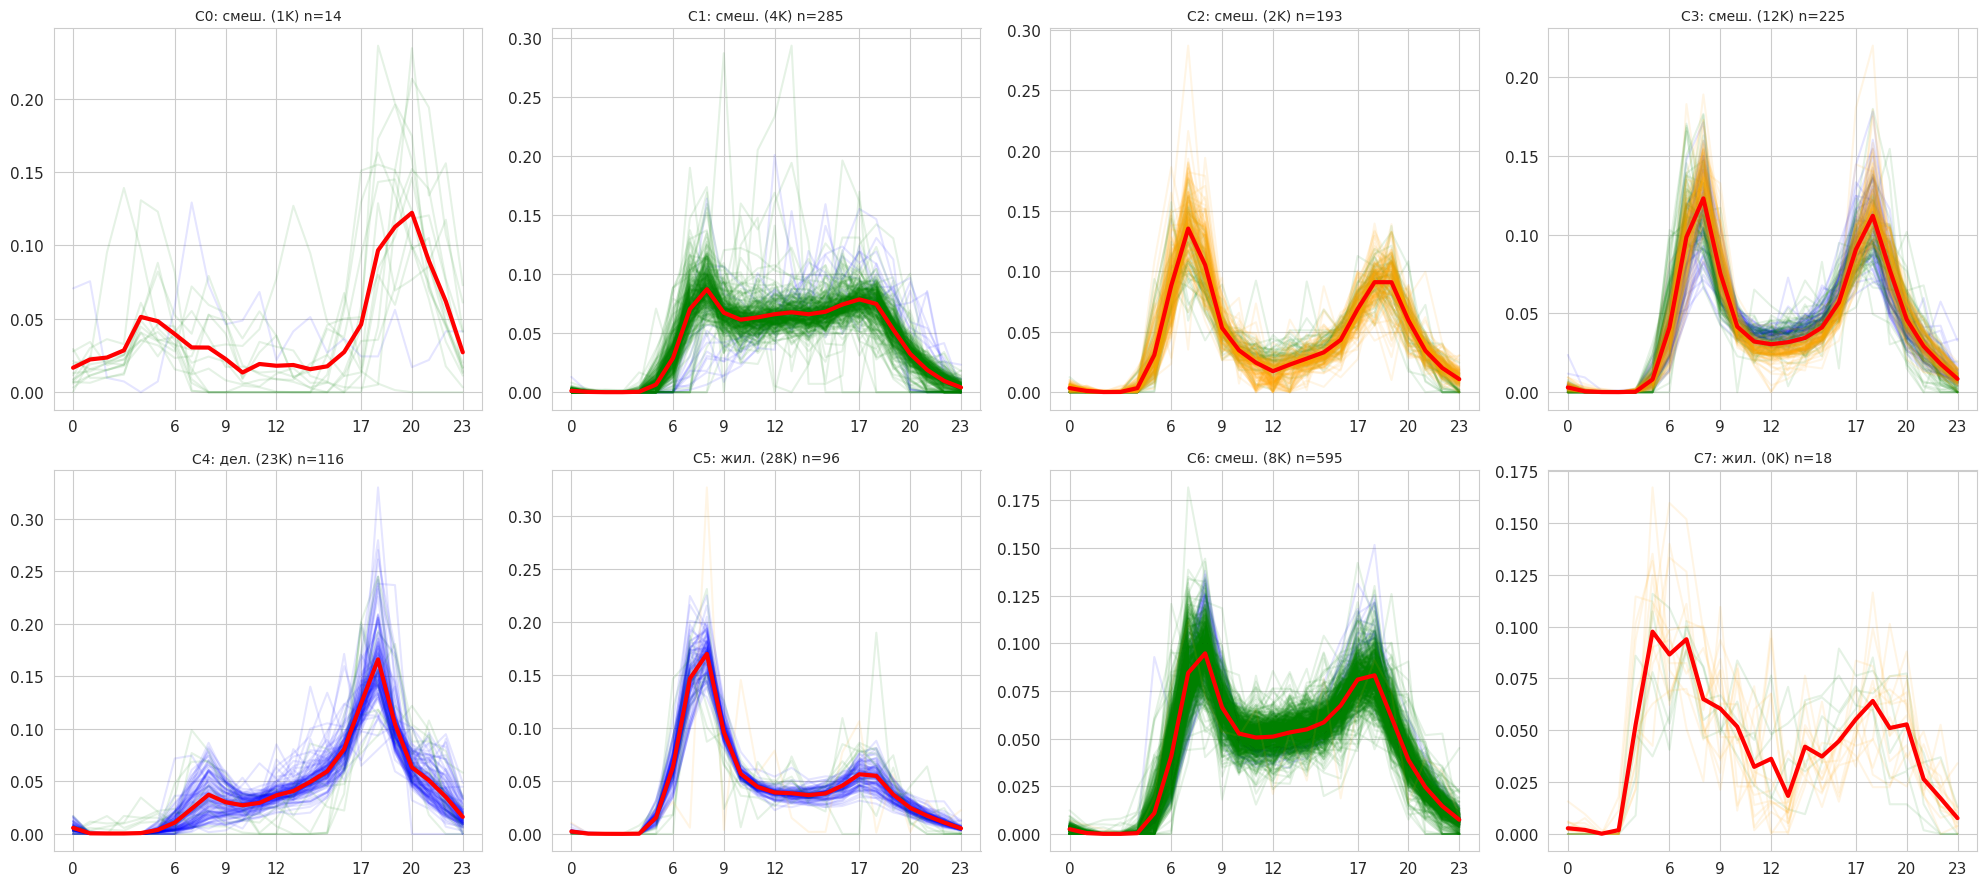

In [34]:
# визуализация профилей
ncols = (final_k + 1) // 2
fig, axes = plt.subplots(2, ncols, figsize=(5*ncols, 9))
axes = axes.ravel()
colors = {'Метро':'blue', 'НГПТ':'green', 'МЦД':'orange'}

for c in range(final_k):
    ax = axes[c]
    sub = af[af.cluster == c]
    for _, row in sub.iterrows():
        ax.plot(range(24), [row[f'wd_h{h}'] for h in range(24)],
                alpha=0.1, color=colors[row.transport])
    ax.plot(range(24), sub[profile_cols].mean().values, 'r-', lw=3)
    me = sub.morn_eve_ratio.mean()
    lab = "жил." if me > 1.3 else ("дел." if me < 0.75 else "смеш.")
    ax.set_title(f'C{c}: {lab} ({sub.daily_volume.mean()/1000:.0f}K) n={len(sub)}', fontsize=10)
    ax.set_xticks([0,6,9,12,17,20,23])
for i in range(final_k, len(axes)): axes[i].set_visible(False)
plt.tight_layout(); plt.savefig('./eda_output/clust_profiles.png', dpi=150); plt.show()

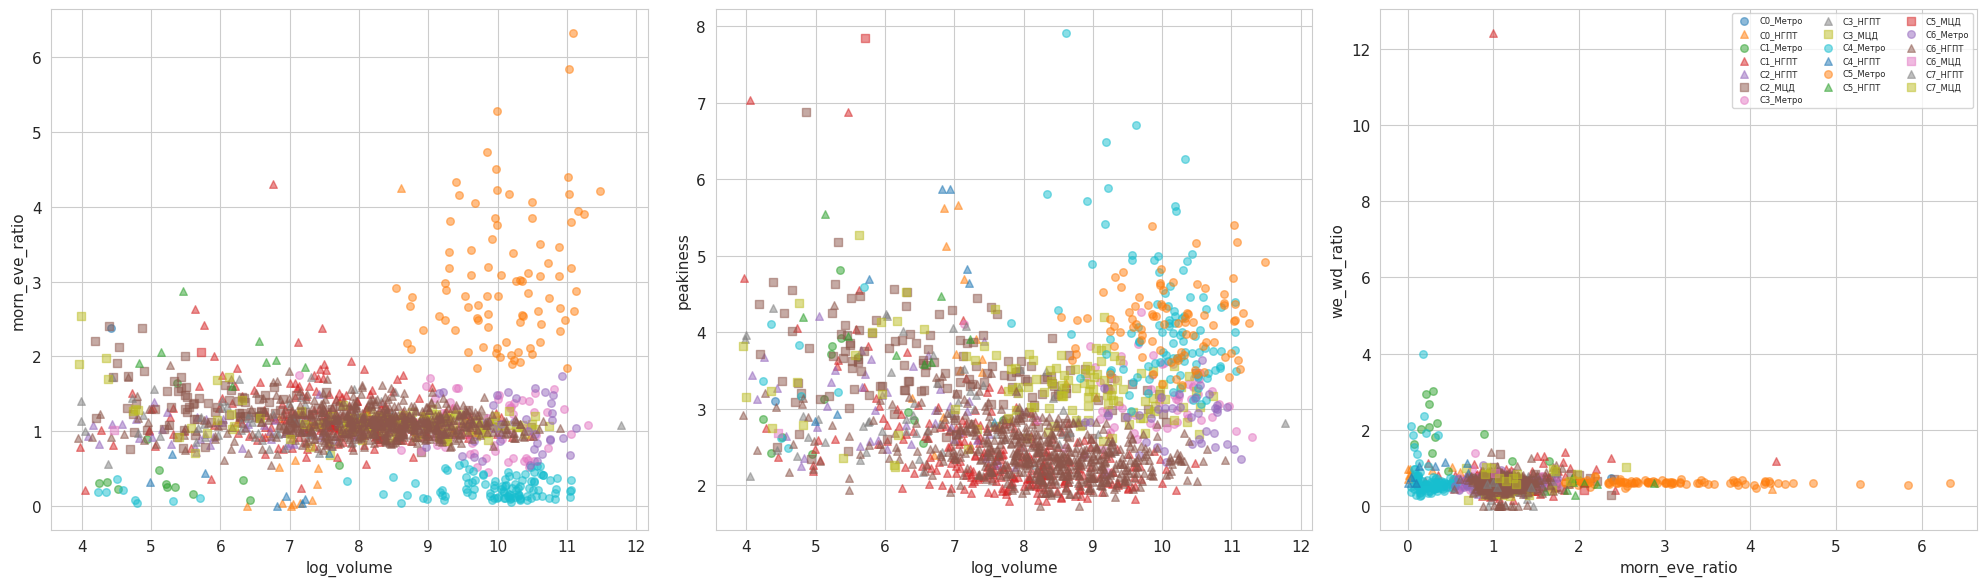

In [35]:
# scatter
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
combos = [('log_volume','morn_eve_ratio'), ('log_volume','peakiness'),
          ('morn_eve_ratio','we_wd_ratio')]
markers = {'Метро':'o', 'НГПТ':'^', 'МЦД':'s'}

for ax, (x, y) in zip(axes, combos):
    for c in sorted(af.cluster.unique()):
        for tr, mk in markers.items():
            sub = af[(af.cluster==c) & (af.transport==tr)]
            if len(sub):
                ax.scatter(sub[x], sub[y], marker=mk, s=30, alpha=0.5, label=f'C{c}_{tr}')
    ax.set_xlabel(x); ax.set_ylabel(y)
axes[2].legend(fontsize=6, ncol=3)
plt.tight_layout(); plt.savefig('./eda_output/clust_scatter.png', dpi=150); plt.show()

### Сохранение

In [36]:
cluster_names = {}
for c in sorted(af.cluster.unique()):
    sub = af[af.cluster == c]
    me, vol = sub.morn_eve_ratio.mean(), sub.daily_volume.mean()
    nm = "Жилой" if me > 1.3 else ("Деловой" if me < 0.75 else "Смешанный")
    nm += " крупный" if vol > 20000 else (" средний" if vol > 5000 else (" малый" if vol > 1000 else " мелкий"))
    dom = sub.transport.value_counts()
    if dom.iloc[0] / len(sub) > 0.7:
        nm += f" ({dom.index[0]})"
    cluster_names[c] = nm

af['cluster_name'] = af.cluster.map(cluster_names)

save_cols = ['object_id','object_name','transport','cluster','cluster_name',
             'LN_CODE','LN_NAME','daily_volume','log_volume',
             'morn_eve_ratio','we_wd_ratio','peakiness','night_share','midday_share']

af[save_cols].to_csv('./eda_output/final_clusters.csv', index=False)
print(f"Сохранено: {len(af)} объектов, {final_k} кластеров")
for c, nm in cluster_names.items():
    print(f"  C{c}: {nm} ({(af.cluster==c).sum()})")

Сохранено: 1542 объектов, 8 кластеров
  C0: Смешанный малый (НГПТ) (14)
  C1: Смешанный малый (НГПТ) (285)
  C2: Смешанный малый (МЦД) (193)
  C3: Смешанный средний (225)
  C4: Деловой крупный (Метро) (116)
  C5: Жилой крупный (Метро) (96)
  C6: Смешанный средний (НГПТ) (595)
  C7: Жилой мелкий (МЦД) (18)




# Выводы по EDA

**Данные** охватывают 1 542 объекта (314 станций метро, 462 маршрута НГПТ, 266 станций МЦД). Основной объём проходов приходится на метро, затем НГПТ и МЦД.

**Временные паттерны** выражены очень чётко. Суточный профиль имеет два пика — утренний (7–9) и вечерний (17–19), на выходных пики сглаживаются и смещаются к середине дня. Недельная сезонность сильная (F=1.0 по STL), при этом ряд нестационарен даже после первого дифференцирования (ADF p=0.48), что говорит о наличии тренда или структурных сдвигов в данных.

**Корреляция** между станциями умеренная (медиана 0.80), при этом станции одной линии коррелируют практически так же, как станции разных (0.68 vs 0.67) — профили потока определяются скорее типом станции (жилая/деловая), чем принадлежностью к линии.

**Стабильность** объектов сильно различается. Наиболее нестабильны речные причалы и станции-новостройки (CV до 0.8), самые стабильные — крупные станции типа Партизанской, Площади Революции (CV < 0.06).

**Кластеризация** выделила 8 групп с интерпретируемой логикой:
- **C4 (Деловой)** — 116 станций метро центра, вечерний пик сильнее утреннего (у/в=0.25), активность на выходных сохраняется (вых/буд=0.70)
- **C5 (Жилой)** — 96 крупных станций спальных районов, утренний пик доминирует (у/в=2.95), на выходных поток падает (вых/буд=0.61)
- **C2, C7** — станции МЦД, средние и мелкие, с ярко выраженным маятниковым характером
- **C1, C6** — основная масса маршрутов НГПТ, смешанный профиль
- **C0** — 14 нетипичных маршрутов НГПТ с пониженным утренним пиком

Выявленные паттерны подтверждают, что для прогнозирования ключевыми признаками являются час суток, тип дня (будни/выходные) и принадлежность объекта к функциональному кластеру.